# Preparing The Data For the Tutorial

This notebook is going to do some basic preparation for the ML tutorial at the Cargese summer school.

Let's first do some imports:

In [1]:
# make plots interactive and import plotting functionality
import matplotlib.pyplot as plt

# pretty plotting
import seaborn as sns

# my standard styles for plots
sns.set_style("whitegrid")
sns.set_context("talk")

# Always need numpy
import numpy as np

# data array operations
import pandas as pd


I want to get some data via SQL query:

In [3]:
from astroquery.sdss import SDSS

Original query:

In [4]:
SDSS.query_sql("""SELECT *,dered_u - mag_u AS diff_u, dered_g - mag_g AS diff_g, dered_r - mag_r AS diff_g, dered_i - mag_i AS diff_i, dered_z - mag_z AS diff_z from (SELECT top 1000
objid, ra, dec, dered_u,dered_g,dered_r,dered_i,dered_z,psfmag_u-extinction_u AS mag_u,
psfmag_g-extinction_g AS mag_g, psfmag_r-extinction_r AS mag_r, psfmag_i-extinction_i AS mag_i,psfmag_z-extinction_z AS mag_z,z AS spec_z,dered_u - dered_g AS u_g_color, 
dered_g - dered_r AS g_r_color,dered_r - dered_i AS r_i_color,dered_i - dered_z AS i_z_color,class
FROM SpecPhoto 
WHERE 
 (class = 'QSO')
 ) as sp
""")

objid,ra,dec,dered_u,dered_g,dered_r,dered_i,dered_z,mag_u,mag_g,mag_r,mag_i,mag_z,spec_z,u_g_color,g_r_color,r_i_color,i_z_color,class,diff_u,diff_g,diff_g1,diff_i,diff_z
uint64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str3,float64,float64,float64,float64,float64
1237648720142532813,146.90229,-0.98491332,19.70227,19.34294,19.28379,19.1772,19.14497,19.77544,19.4076,19.3587,19.27215,19.22411,0.6524171,0.3593292,0.0591507,0.1065845,0.03223419,QSO,-0.0731678,-0.06465721,-0.07491112,-0.09494781,-0.07914162
1237650795146379439,146.438,-0.65600998,19.4376,19.3103,19.16357,19.03476,19.12628,19.44396,19.32273,19.16514,19.03704,19.13457,1.473592,0.1273041,0.1467247,0.1288128,-0.09152222,QSO,-0.006361008,-0.01243591,-0.001573563,-0.002281189,-0.008295059
1237651801233490042,148.56975,0.13592029,19.42949,18.97614,18.84135,18.85753,18.86819,19.44996,18.99802,18.88481,18.90536,18.91494,0.8849242,0.4533501,0.1347961,-0.01618195,-0.01065445,QSO,-0.02046204,-0.02187729,-0.04345703,-0.04782867,-0.04675293
1237650796220907565,148.18988,0.0043093332,19.13014,19.05478,18.81401,18.81901,18.84225,19.11135,19.07462,18.81429,18.83533,18.85712,1.062692,0.07536125,0.2407722,-0.005002975,-0.02323723,QSO,0.01878929,-0.01983643,-0.0002841949,-0.01631165,-0.0148716
1237650795147231365,148.34861,-0.63410067,18.62675,18.57638,18.41098,18.4198,18.44879,18.63688,18.59998,18.41267,18.42163,18.4533,1.384028,0.05037117,0.1653996,-0.00881958,-0.02898979,QSO,-0.01013374,-0.02360535,-0.00169754,-0.001831055,-0.00451088
1237650796220710992,147.77177,0.013687602,18.71038,18.43969,18.44365,18.52569,18.44529,18.71894,18.44034,18.45102,18.5297,18.45192,0.8751809,0.2706871,-0.00396347,-0.08203697,0.08039856,QSO,-0.008562088,-0.0006542206,-0.007362366,-0.004007339,-0.006628036
1237648720142860487,147.75059,-1.0198861,19.1,18.97405,18.71684,18.67246,18.71611,19.10036,18.97976,18.71384,18.6731,18.70313,1.14837,0.1259556,0.2572041,0.04438782,-0.0436573,QSO,-0.0003547668,-0.005708694,0.003007889,-0.0006465912,0.01298141
1237648721216602444,147.70202,-0.0049211228,21.6564,20.772,20.11009,19.52948,19.29946,21.58172,20.75805,20.09738,19.51366,19.30424,1.8664,0.8844032,0.6619015,0.5806122,0.2300186,QSO,0.07468033,0.01394653,0.01271629,0.01582336,-0.004776001
1237648720679796790,147.87927,-0.50882584,19.57944,18.35622,17.49404,17.05686,16.72954,21.25815,20.2288,19.47206,19.062,18.76805,0.1378086,1.223227,0.862175,0.4371853,0.3273144,QSO,-1.678703,-1.87258,-1.978016,-2.005144,-2.038504


In [5]:
qsos = SDSS.query_sql("""SELECT *,dered_u - mag_u AS diff_u, dered_g - mag_g AS diff_g, dered_r - mag_r AS diff_g, dered_i - mag_i AS diff_i, dered_z - mag_z AS diff_z from (SELECT top 50000
objid, ra, dec, dered_u,dered_g,dered_r,dered_i,dered_z,psfmag_u-extinction_u AS mag_u,
psfmag_g-extinction_g AS mag_g, psfmag_r-extinction_r AS mag_r, psfmag_i-extinction_i AS mag_i,psfmag_z-extinction_z AS mag_z,z AS spec_z,dered_u - dered_g AS u_g_color, 
dered_g - dered_r AS g_r_color,dered_r - dered_i AS r_i_color,dered_i - dered_z AS i_z_color,class
FROM SpecPhoto 
WHERE 
 (class = 'QSO')
 ) as sp
""")

In [6]:
stars = SDSS.query_sql("""SELECT * from (SELECT top 50000
objid, ra, dec, dered_u,dered_g,dered_r,dered_i,dered_z,psfmag_u-extinction_u AS mag_u,
psfmag_g-extinction_g AS mag_g, psfmag_r-extinction_r AS mag_r, psfmag_i-extinction_i AS mag_i,psfmag_z-extinction_z AS mag_z,z AS spec_z,dered_u - dered_g AS u_g_color, 
dered_g - dered_r AS g_r_color,dered_r - dered_i AS r_i_color,dered_i - dered_z AS i_z_color,class
FROM SpecPhoto 
WHERE 
 (class = 'STAR')
 ) as sp
""")

In [7]:
galaxies = SDSS.query_sql("""SELECT * from (SELECT top 50000
objid, ra, dec, dered_u,dered_g,dered_r,dered_i,dered_z,psfmag_u-extinction_u AS mag_u,
psfmag_g-extinction_g AS mag_g, psfmag_r-extinction_r AS mag_r, psfmag_i-extinction_i AS mag_i,psfmag_z-extinction_z AS mag_z,z AS spec_z,dered_u - dered_g AS u_g_color, 
dered_g - dered_r AS g_r_color,dered_r - dered_i AS r_i_color,dered_i - dered_z AS i_z_color,class
FROM SpecPhoto 
WHERE 
 (class = 'GALAXY')
 ) as sp
""")

In [8]:
qsos = qsos.to_pandas()
qsos["class"] = np.array(qsos["class"], dtype=str)

In [9]:
stars = stars.to_pandas()
stars["class"] = np.array(stars["class"], dtype=str)

In [10]:
galaxies = galaxies.to_pandas()
galaxies["class"] = np.array(galaxies["class"], dtype=str)

In [11]:
comb = pd.concat([stars, galaxies])

## Machine Learning With Messy Data

Try to do machine learning on the original data as is. Let's get out the classes first!

In [12]:
classes = np.array(comb["class"], dtype=str)

Let's just separate out 55% of data as a test set (that's a little high, but why will become clear a bit further down below), and the rest as training set (we'll worry about validation sets in a little while!).

In [13]:
len(classes)

100000

In [14]:
ntraining = int(len(classes)*0.51)

In [15]:
ntest = int(len(classes) - ntraining)

In [16]:
print("There are %i training samples."%ntraining)
print("There are %i test samples."%ntest)

There are 51000 training samples.
There are 49000 test samples.


Split out test and training sets:

In [17]:
X_train = comb[:ntraining]
X_test = comb[ntraining:]

Note: the thing you're classifying on should *not* be part of the array you use to classify!

In [18]:
X_train = X_train.drop("class", axis=1)
X_test = X_test.drop("class", axis=1)

In [19]:
len(X_train)

51000

In [20]:
l_train = classes[:ntraining]
l_test = classes[ntraining:]

Now let's set up a simple classifier. Try one of a logitistic regression classifier, Support Vector Machine or Random Forest. Or try all three. Start with the default parameters:

In [21]:
from sklearn import linear_model

In [22]:
lr = linear_model.LogisticRegression()

In [23]:
lr.fit(X_train, l_train)

LogisticRegression()

In [24]:
lr.score(X_train, l_train)

0.9803921568627451

In [25]:
lr.score(X_test, l_test)

0.0

Whoa! We classified zero (!) samples correctly! That's not great. **What do you think happened?**


There are a bunch of steps we've left out. Remember how I said **look at the data first**. 

## Exploring Data For Machine Learning

**Exercise 1**: Plot some of the quantities in the table. What do you notice? Can you use the data as is? 

**Solution**: Let's plot the magnitudes to see what they look like.

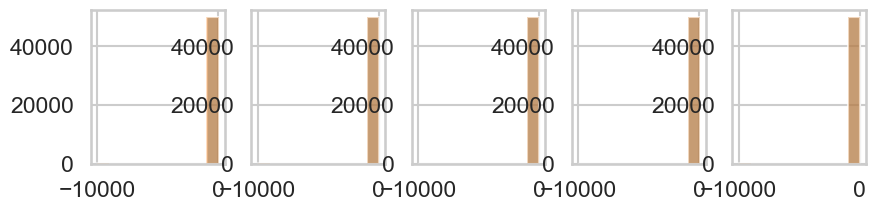

In [26]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, m in enumerate(["mag_u", "mag_g", "mag_r", "mag_i", "mag_z"]):
        axes[i].hist(comb.loc[comb["class"] == "STAR", m], histtype="stepfilled", color=sns.color_palette()[0], alpha=0.5)
        axes[i].hist(comb.loc[comb["class"] == "GALAXY", m], histtype="stepfilled", color=sns.color_palette()[1], alpha=0.5)

Okay, what you should notice is that there are clearly data points in there with a magnitude of -10000. That's clearly not real. These are objects for which the magnitude is essentially NaN. Many tables can't deal with NaNs, so people set them to a number that the value definitely can't be. In many instances, that's 0, but 0 is actually a sensible magnitude, so we can't use it here. -10000 is definitely not a sensible magnitude, however, indicating that there's something seriously wrong with those data points. 

How many of those are there:

In [27]:
len(comb.loc[(comb["mag_u"] < -1000) | (comb["mag_r"] < -1000) | (comb["mag_g"] < -1000) | (comb["mag_i"] < -1000) | (comb["mag_z"] < -1000)])


68

In [28]:
len(comb.loc[(comb["mag_u"] > -1000) & (comb["mag_r"] > -1000) & (comb["mag_g"] > -1000) & (comb["mag_i"] > -1000) & (comb["mag_z"] > -1000)])

99932

That's not very many, but enough to mess up the classification, I think. Let's make a clean version without those:

In [29]:
comb_clean = comb.loc[(comb["mag_u"] > -1000) & (comb["mag_r"] > -1000) & (comb["mag_g"] > -1000) & (comb["mag_i"] > -1000) & (comb["mag_z"] > -1000)]

**Exercise 1**: There are a lot of different quantities in the data, including the magnitudes, the dereddened magnitudes and the differences between dereddened and other magnitudes (you can look up some details [here](http://skyserver.sdss.org/dr14/en/help/browser/browser.aspx#&&history=description+SpecPhoto+V). Which ones might make a good feature for classifications? Can you think of physical reasons why some might make better features for classifying stars versus galaxies than others? Can you think of ways to figure out from the data (e.g. via plotting) how to assess the usefulness of features? Discuss with your group!

Let's make some pairplots to explore the features.

First, just the magnitudes:

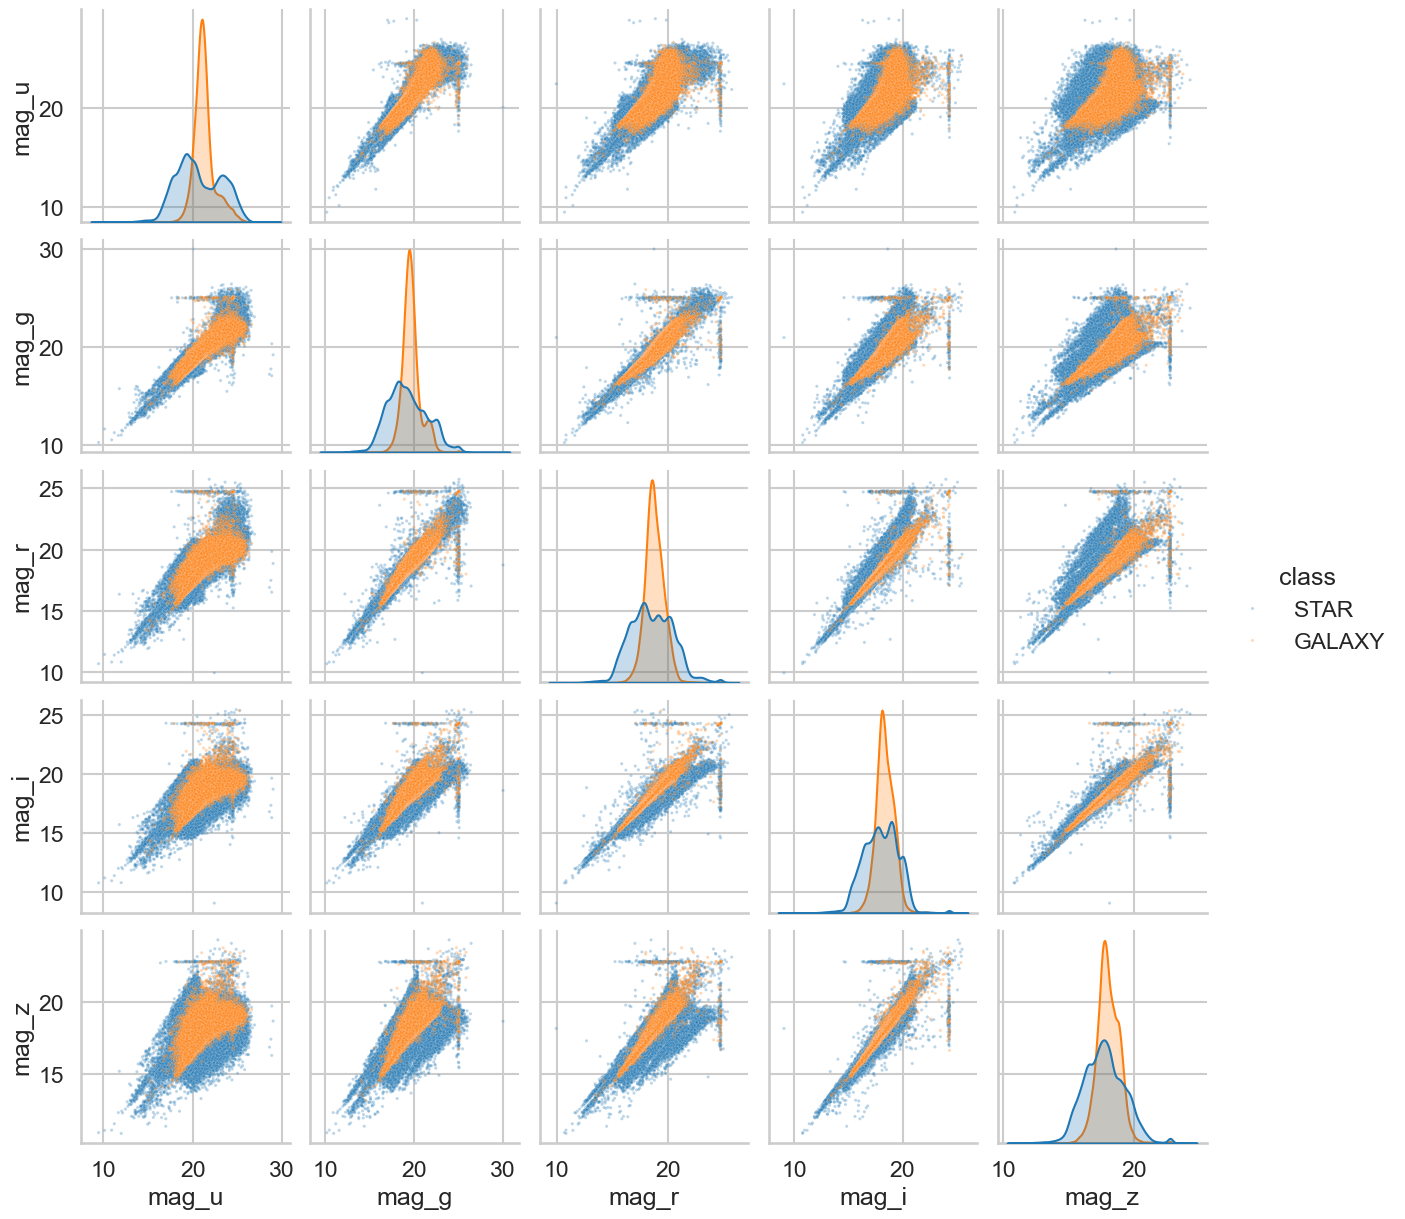

In [30]:
sns.pairplot(comb_clean[["mag_u", "mag_g", "mag_r", "mag_i", "mag_z", "class"]], 
             hue="class", diag_kind="kde", plot_kws={"alpha":0.3, "s":5})

What about the colours?

In [31]:
comb.columns

Index(['objid', 'ra', 'dec', 'dered_u', 'dered_g', 'dered_r', 'dered_i',
       'dered_z', 'mag_u', 'mag_g', 'mag_r', 'mag_i', 'mag_z', 'spec_z',
       'u_g_color', 'g_r_color', 'r_i_color', 'i_z_color', 'class'],
      dtype='object')

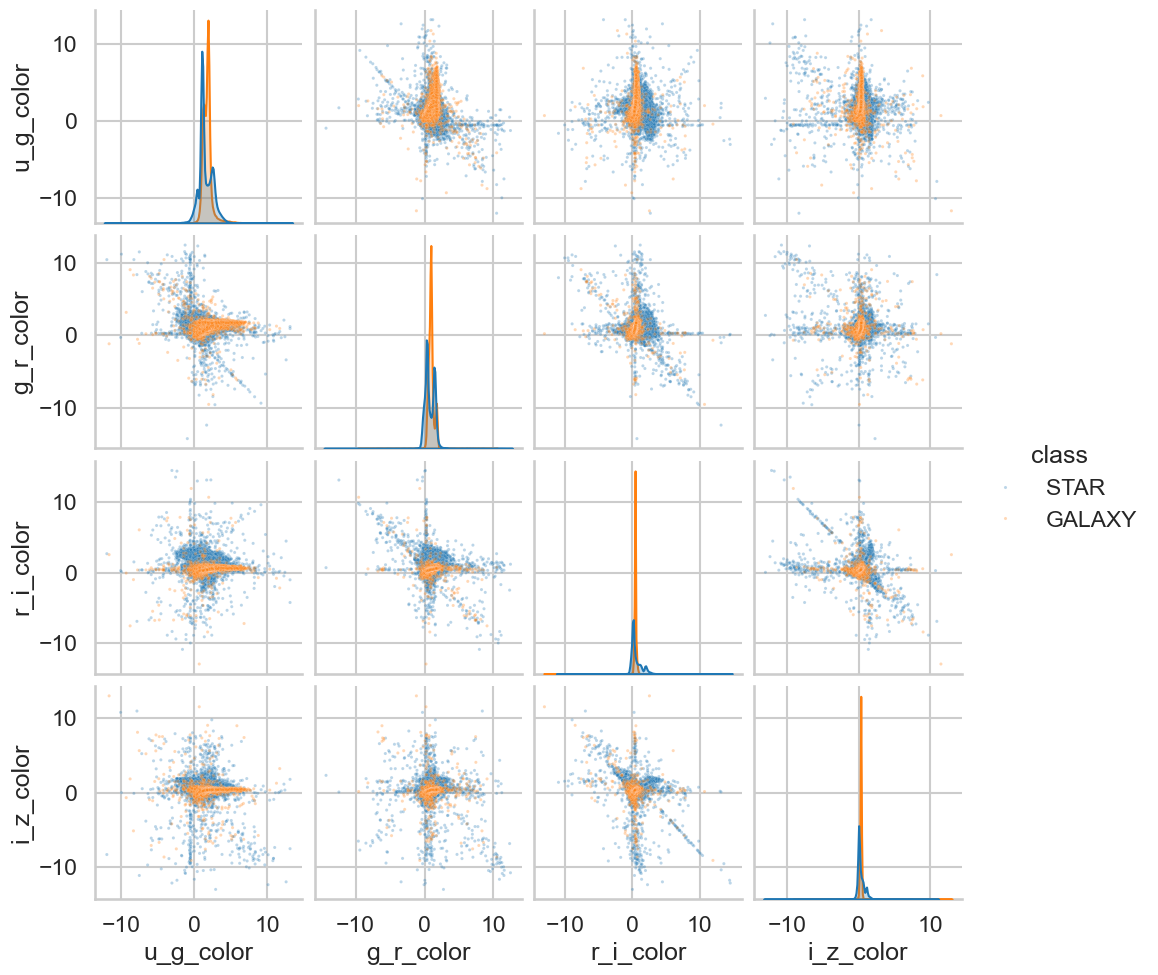

In [32]:
sns.pairplot(comb_clean[['u_g_color', 'g_r_color', 'r_i_color', 'i_z_color', "class"]], 
             hue="class", diag_kind="kde", plot_kws={"alpha":0.3, "s":5})

What about the dereddened colours?

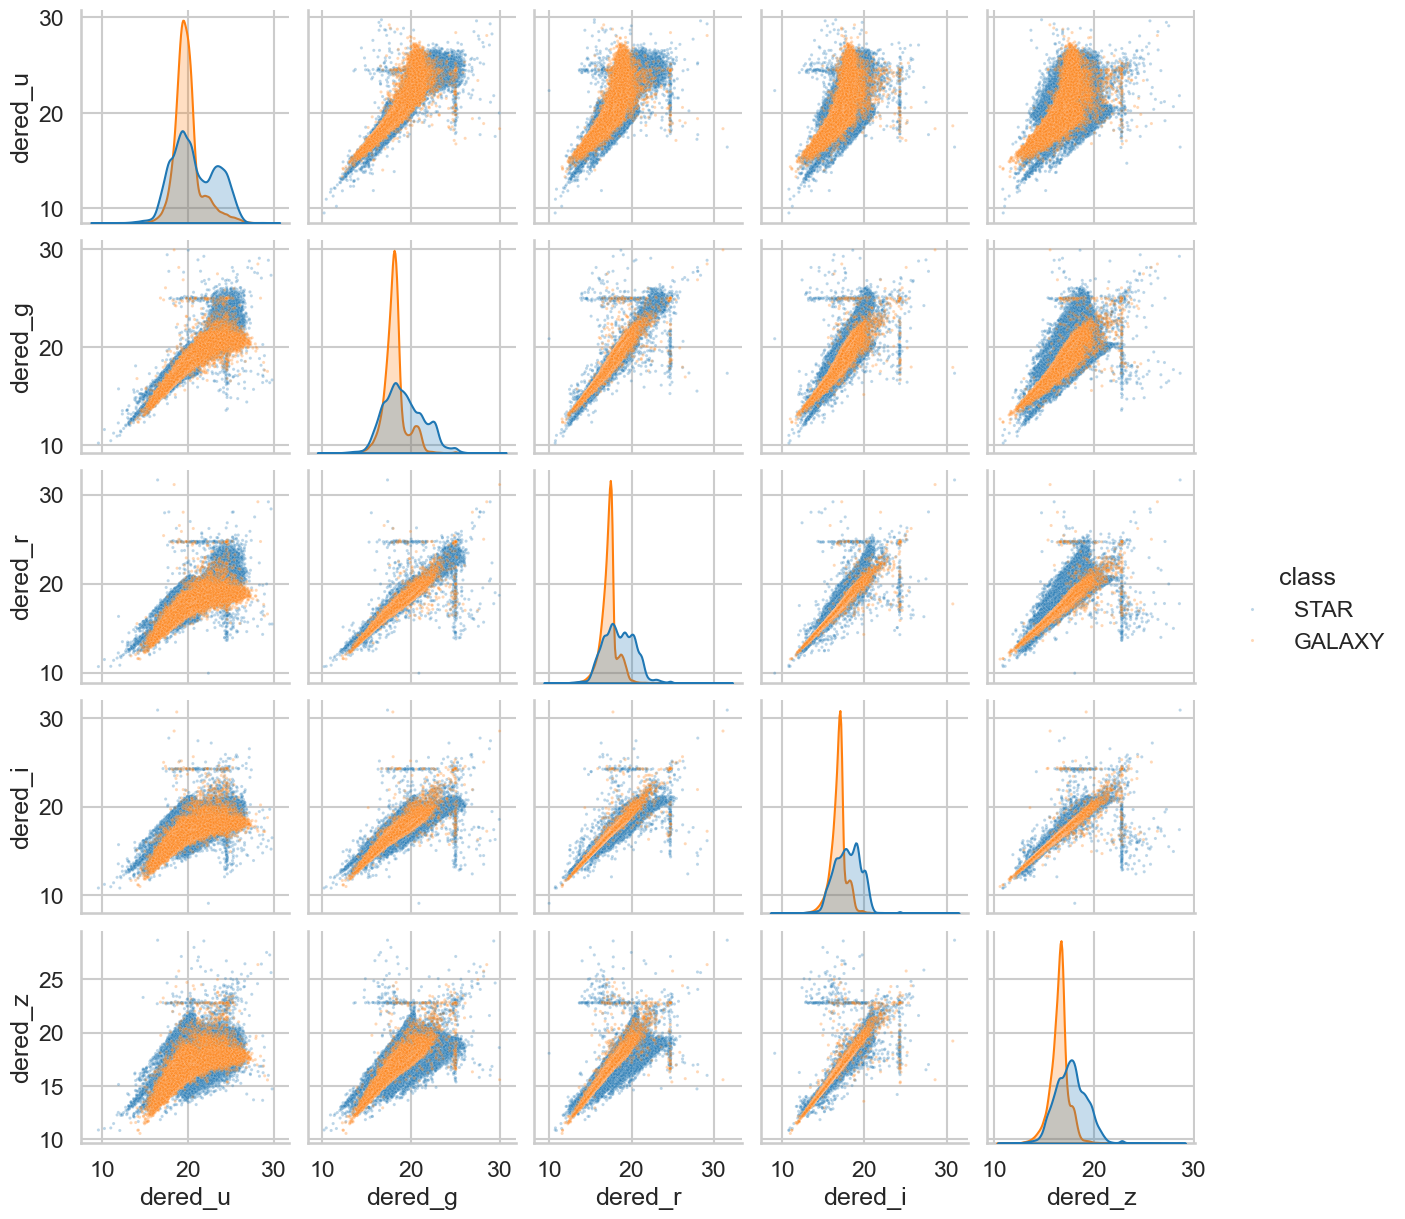

In [33]:
sns.pairplot(comb_clean[['dered_u', 'dered_g', 'dered_r', 'dered_i','dered_z', "class"]], 
             hue="class", diag_kind="kde", plot_kws={"alpha":0.3, "s":5})

Let's try to do the same classification again, on the cleaned versions:

In [34]:
X_train = comb_clean[:ntraining]
X_test = comb_clean[ntraining:]
X_train = X_train.drop("class", axis=1)
X_test = X_test.drop("class", axis=1)

In [35]:
classes = np.array(comb_clean["class"], dtype=str)
l_train = classes[:ntraining]
l_test = classes[ntraining:]

In [36]:
lr = linear_model.LogisticRegression()
lr.fit(X_train, l_train)
print("Training accuracy: " + str(lr.score(X_train, l_train)))
print("Test accuracy: " + str(lr.score(X_test, l_test)))

Training accuracy: 0.9801960784313726
Test accuracy: 0.0


Well, that hasn't really improved much. What else can we do to make the data better?
Let's print the table:

In [37]:
comb_clean.head()

,objid,ra,dec,dered_u,dered_g,dered_r,dered_i,dered_z,mag_u,mag_g,mag_r,mag_i,mag_z,spec_z,u_g_color,g_r_color,r_i_color,i_z_color,class
0,1237651752385249327,146.98697,0.909942,18.29787,17.16595,16.72356,16.56242,16.45597,18.31136,17.17108,16.73147,16.57583,16.45248,-0.000189,1.131924,0.442390,0.161137,0.106445,STAR
1,1237650796757319859,147.16763,0.471673,19.10346,18.04541,18.08642,18.16432,18.27734,19.09775,18.04198,18.07654,18.16775,18.27693,0.000014,1.058048,-0.041006,-0.077904,-0.113012,STAR
2,1237651801769705649,147.18683,0.587952,17.73738,17.39039,17.75780,17.94205,18.24037,17.75833,17.39104,17.75389,17.95208,18.20596,0.000145,0.346996,-0.367416,-0.184250,-0.298317,STAR
3,1237654669198295120,148.96675,-0.776078,21.34169,19.02872,17.64830,17.02935,16.69153,21.33948,19.02627,17.65767,17.04221,16.69152,0.000101,2.312969,1.380424,0.618944,0.337826,STAR
4,1237648720143188043,148.52640,-0.971689,18.33641,17.24536,16.89229,16.78181,16.75326,18.32882,17.24148,16.89594,16.77729,16.74926,0.000459,1.091057,0.353067,0.110479,0.028551,STAR


For one, there are a whole bunch of categories we probably don't want to classify on. The `objid` column encodes an identifier for each object, which is probably not practically meaningful for classification. Similarly, it is unlikely that RA and Dec help us meaningfully (although note that in some cases, it might be useful to keep this in to take into account instrumental effects):

In [38]:
ml_categories = comb_clean.drop(["objid", "ra", "dec", "class"], axis=1)

In [39]:
X_train = ml_categories[:ntraining]
X_test = ml_categories[ntraining:]

In [40]:
len(l_train[l_train == "GALAXY"])

1010

In [41]:
lr = linear_model.LogisticRegression()
lr.fit(X_train, l_train)
print("Training accuracy: " + str(lr.score(X_train, l_train)))
print("Test accuracy: " + str(lr.score(X_test, l_test)))

Training accuracy: 0.9881960784313726
Test accuracy: 0.603429248753372


/Users/danielahuppenkothen/work/sw/w/miniforge3/envs/teaching/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Oh, hey, look, that suddenly fixed a lot of things! It's still not great! 

**Hint**: Take a look at the top and the bottom of the table. What do you notice?

**Solution**: One thing you should notice is that the data is sorted: the top examples are all stars, the bottom examples are all galaxies! So if we take the top 51%, then that'll include almost only stars, and almost no galaxies. But then we test on the bottom 49%, which are all galaxies!

This is why *randomization* is a standard technique in machine learning! This may not work for all problems (e.g. in time series, where the ordering is actually important!), but in many cases, you actively *want* to randomize so that your **training data set and your validation and test sets are drawn from the same distribution**. A biased training data set is one of the most common reasons for why machine learning models may not perform well in practice, or for why results of these models may be biased!

This is where we introduce another useful function in scikit-learn: [`train_test_split`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). This function automatically splits data into training and test sets, as we've done above by hand, and by default shuffles them. Let's do that:

In [42]:
from sklearn.model_selection import train_test_split

We're going to define a `RandomState` object. This sets the random number generator used in the shuffling, such that every time I run this notebook I get out **the same training and test sets**. This helps a lot with being able to reproduce results:

In [43]:
rng = np.random.RandomState(100)

We're going to choose a better train-test split here (since we chose 51% as a contrived example to show what happens when you have ordered data and don't shuffle):

In [44]:
X_train, X_test, l_train, l_test = train_test_split(ml_categories, classes, test_size=0.25, random_state=rng)

Let's take a look what our list of training examples looks like:

In [45]:
l_train

array(['STAR', 'GALAXY', 'GALAXY', ..., 'GALAXY', 'GALAXY', 'STAR'],
      dtype='<U6')

This should now be shuffled (it looks that way). 

Cool, what does our classification look like now?

In [46]:
lr = linear_model.LogisticRegression()
lr.fit(X_train, l_train)
print("Training accuracy: " + str(lr.score(X_train, l_train)))
print("Test accuracy: " + str(lr.score(X_test, l_test)))

Training accuracy: 0.9912473815527892
Test accuracy: 0.9901132770283793


/Users/danielahuppenkothen/work/sw/w/miniforge3/envs/teaching/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Sweet! Our test and training accuracy are up to >99% with nothing but making sure the data is vaguely sensible!

## Machine Learning With Imbalanced Data Sets: Finding (Rare) Stars!

Imagine we had a survey where stars are rare, and galaxies dominate our catalogue. Imagine, however, that stars were super interesting, and we really, really wanted to find all the stars in our catalogue. This is what we're going to try and do in this exercise!

* explore imbalanced data sets
* figure out strategies to make sure you do the right thing
* different types of loss functions
* different types of splitting train/validation/test sets

#### Preparing the Data
Let's first prepare the data, so I can store it in a file:

In [47]:
mask = np.array(comb["class"] == "GALAXY")

In [48]:
ml_imbalance = comb[mask]

In [49]:
mask = np.array(comb["class"] == "STAR")
ml_imbalance2 = comb[mask]

In [50]:
mask = np.array(comb["mag_z"] < -1000)
ml_imbalance3 = comb[mask]

In [51]:
comb[mask]["class"]

850        STAR
1096       STAR
2773       STAR
3917       STAR
17744      STAR
18866      STAR
27575      STAR
43082      STAR
1352     GALAXY
3539     GALAXY
3618     GALAXY
3692     GALAXY
3716     GALAXY
4478     GALAXY
4510     GALAXY
5108     GALAXY
5286     GALAXY
5935     GALAXY
6168     GALAXY
6784     GALAXY
6891     GALAXY
7462     GALAXY
8209     GALAXY
9160     GALAXY
9271     GALAXY
10292    GALAXY
10337    GALAXY
11442    GALAXY
12114    GALAXY
12241    GALAXY
13277    GALAXY
13343    GALAXY
14396    GALAXY
16466    GALAXY
16652    GALAXY
16673    GALAXY
17092    GALAXY
17134    GALAXY
17189    GALAXY
17458    GALAXY
18216    GALAXY
18712    GALAXY
18806    GALAXY
19357    GALAXY
19808    GALAXY
19841    GALAXY
19964    GALAXY
20384    GALAXY
20411    GALAXY
20560    GALAXY
20846    GALAXY
25225    GALAXY
26420    GALAXY
26488    GALAXY
27495    GALAXY
28069    GALAXY
28165    GALAXY
40073    GALAXY
Name: class, dtype: object

In [52]:
n_stars = 500
n_wrong = len(ml_imbalance3)
n_galaxies = 20000 - n_stars - n_wrong

In [53]:
ml_imbalance = pd.concat([ml_imbalance[:n_galaxies], ml_imbalance3[ml_imbalance3["class"] == "GALAXY"], 
                          ml_imbalance2[:n_stars], ml_imbalance3[ml_imbalance3["class"] == "STAR"]])

In [54]:
ml_imbalance.to_csv("sdss_dataset1_new.csv", index=False)

### Running the ML

Let's first load our data. For this exercise, we use the data file `sdss_dataset1.csv`:

In [408]:
data = pd.read_csv("sdss_dataset1.csv")

Let's take a look at that data:

In [409]:
data.head()

,objid,ra,dec,dered_u,dered_g,dered_r,dered_i,dered_z,mag_u,mag_g,mag_r,mag_i,mag_z,spec_z,u_g_color,g_r_color,r_i_color,i_z_color,class
0,1237648721216405657,147.24805,-0.035724,19.92408,17.75023,16.76577,16.31368,15.98227,21.04040,19.02146,18.03189,17.63901,17.28919,0.084197,2.173847,0.984457,0.452093,0.331408,GALAXY
1,1237648721216274720,146.92403,-0.105143,23.76510,20.41189,18.60511,17.97406,17.66566,23.76242,21.48446,19.66513,19.17169,18.82085,0.327572,3.353209,1.806780,0.631050,0.308403,GALAXY
2,1237650795683446969,146.92010,-0.306462,19.41834,18.03791,17.10992,16.70166,16.41131,20.86501,19.79343,18.81922,18.41781,18.10752,0.131480,1.380424,0.927998,0.408258,0.290352,GALAXY
3,1237650796220514489,147.32951,0.028903,17.59556,16.01916,15.31942,14.94442,14.66613,19.76252,18.20831,17.44802,17.07813,16.77753,0.048086,1.576405,0.699732,0.374999,0.278297,GALAXY
4,1237650795683512955,147.08969,-0.266509,24.22258,21.01025,19.29160,18.66112,18.20660,24.17756,21.58750,19.87928,19.27138,18.83974,0.382936,3.212330,1.718651,0.630482,0.454517,GALAXY


In [410]:
data["class"]

0       GALAXY
1       GALAXY
2       GALAXY
3       GALAXY
4       GALAXY
5       GALAXY
6       GALAXY
7       GALAXY
8       GALAXY
9       GALAXY
10      GALAXY
11      GALAXY
12      GALAXY
13      GALAXY
14      GALAXY
15      GALAXY
16      GALAXY
17      GALAXY
18      GALAXY
19      GALAXY
20      GALAXY
21      GALAXY
22      GALAXY
23      GALAXY
24      GALAXY
25      GALAXY
26      GALAXY
27      GALAXY
28      GALAXY
29      GALAXY
         ...  
9970      STAR
9971      STAR
9972      STAR
9973      STAR
9974      STAR
9975      STAR
9976      STAR
9977      STAR
9978      STAR
9979      STAR
9980      STAR
9981      STAR
9982      STAR
9983      STAR
9984      STAR
9985      STAR
9986      STAR
9987      STAR
9988      STAR
9989      STAR
9990      STAR
9991      STAR
9992      STAR
9993      STAR
9994      STAR
9995      STAR
9996      STAR
9997      STAR
9998      STAR
9999      STAR
Name: class, Length: 10000, dtype: object

**Exercise**: Implement a simple k-nearest neighbour classifier without any pre-processing of this data. What steps do you need to take first? If you do that, what happens? Record your classification performance.

**Hint**: You'll need to split your data into training and test sets (let's say 50% for each). You'll also need to split out the *labels* (i.e. the classes you want to classify the data in) from the existing data frame. 

**Hint 2**: You can record your classification performance using the `score` method. This method will predict labels for all examples, and then compare the predicted labels to the true labels. The *accuracy* is the fraction of samples for which the predicted and true labels match, and is what's by default returned by `score`.


**Solution**: Let's first split out the classes:

In [411]:
labels = data["class"]

features = data.drop("class", axis=1)

In [412]:
from sklearn.neighbors import KNeighborsClassifier

In [413]:
ntraining = int(len(features)*0.5)

In [414]:
X_train = features[:ntraining]
X_test = features[ntraining:]

l_train = labels[:ntraining]
l_test = labels[ntraining:]

In [415]:
kn = KNeighborsClassifier()

In [416]:
kn.fit(X_train, l_train)

KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
           metric_params=None, n_jobs=1, n_neighbors=5, p=2,
           weights='uniform')

The scoring method

In [417]:
kn.score(X_train, l_train)

1.0

In [418]:
kn.score(X_test, l_test)

0.9926

At first glance, this looks pretty good! We classified 100% of our training examples correctly, and 99% of our test set! Cool! Are we done? 

**Exercise**: Explore where the classifier did well, and where it didn't. You can use the `predict` method to actually predict labels for the test set and compare these to the true labels.

**Solution**: Let's make some predictions for the test set:

In [419]:
ltest_pred = kn.predict(X_test)

Let's plot a histogram of the true labels and the predicted labels:

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


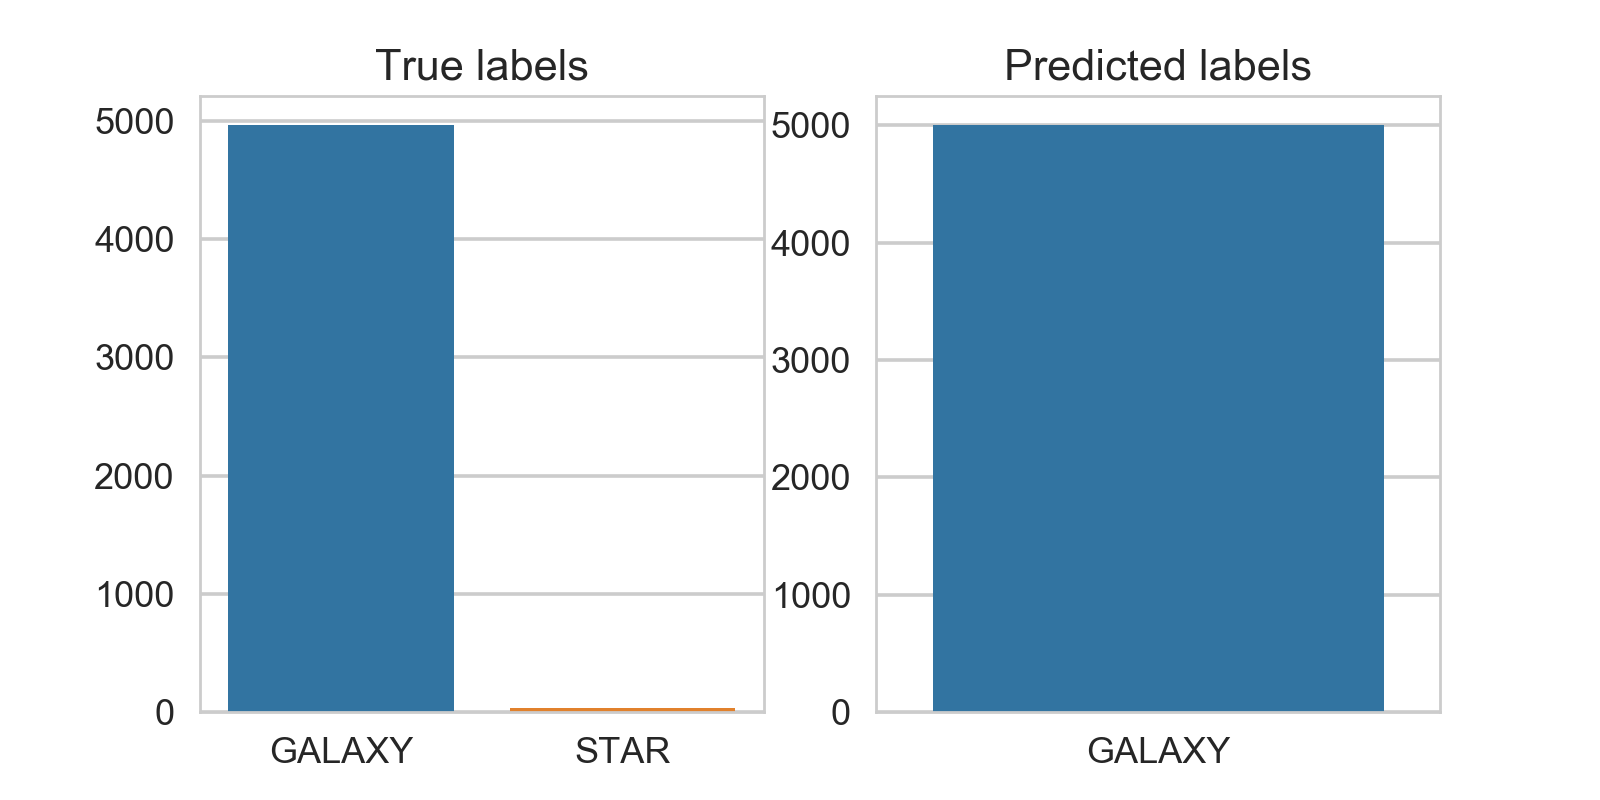

Text(0.5,1,'Predicted labels')

In [420]:
ltest_counts = pd.Series(l_test).value_counts()
ltest_pred_counts = pd.Series(ltest_pred).value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
sns.barplot(ltest_counts.index, ltest_counts.values, ax=ax1)
ax1.set_title("True labels")

sns.barplot(ltest_pred_counts.index, ltest_pred_counts.values, ax=ax2)
ax2.set_title("Predicted labels")

Note that our classifier predicted **no** galaxies in our data! But why?

To figure that out, let's plot the training data:

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


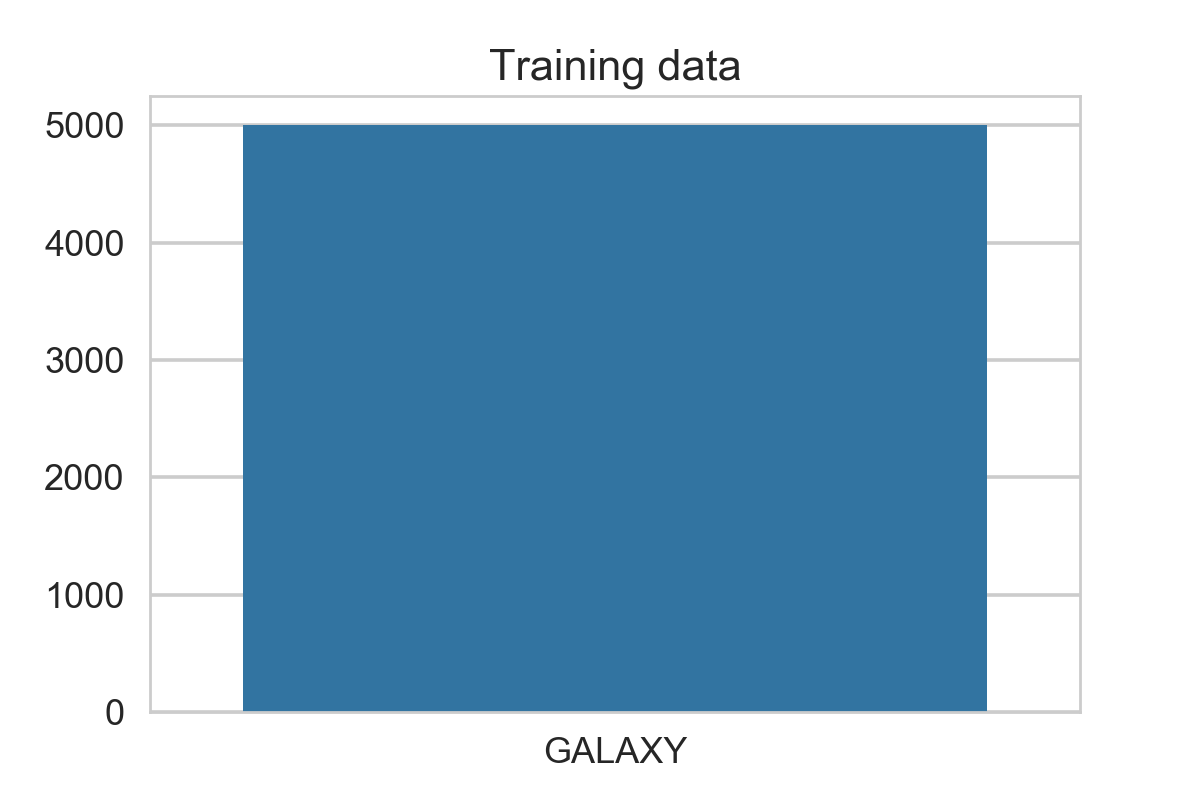

Text(0.5,1,'Training data')

In [421]:
ltrain_counts = pd.Series(l_train).value_counts()

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.barplot(ltrain_counts.index, ltrain_counts.values, ax=ax)
ax.set_title("Training data")


Ah-ha! Here's the solution! Our training data had *no* examples of galaxies in it!

Let's list the labels:

In [70]:
classes

array(['STAR', 'STAR', 'STAR', ..., 'GALAXY', 'GALAXY', 'GALAXY'],
      dtype='<U64')

The reason is that our data is *ordered*: all the galaxies are at the end of the data frame, and we just split the data frame in half in the middle, so all the galaxies ended up in the test set.

If we were really interested in finding galaxies, we'd now be in very big trouble! The accuracy score was high because we have only very few examples of galaxies compared to stars, so mis-classifying those as stars did not have a huge impact on our accuracy. We might have thought that our 99% accuracy is *awesome*, whereas in fact we did a really bad job at finding out what we actually wanted to find out.


**Exercise**: It's time to *look at the data*. Look at the table, make plots of the various quantities. Which quantities do you think will be useful for classification? Which won't? Discuss! What plots are useful to make to help you figure out how to do decide? Are there any peculiarities of the data you should take into account? 


**Solution**: Same plots as above, also take out -10000 measurements and d


In [422]:
mask = (features["mag_z"] < -1000)

In [423]:
len(features[mask])

38

These are bad data, let's exclude them:

In [424]:
features = features[~mask]

In [425]:
len(features)

9962

In [426]:
labels = labels[~mask]

In [427]:
len(labels)

9962


This is why *randomization* is a standard technique in machine learning! This may not work for all problems (e.g. in time series, where the ordering is actually important!), but in many cases, you actively *want* to randomize so that your **training data set and your validation and test sets are drawn from the same distribution**. A biased training data set is one of the most common reasons for why machine learning models may not perform well in practice, or for why results of these models may be biased!

This is where we introduce another useful function in scikit-learn: [`train_test_split`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html). This function automatically splits data into training and test sets, as we've done above by hand, and by default shuffles them. Let's do that:

In [428]:
from sklearn.model_selection import train_test_split

We're going to define a `RandomState` object. This sets the random number generator used in the shuffling, such that every time I run this notebook I get out **the same training and test sets**. This helps a lot with being able to reproduce results:

In [429]:
rng = np.random.RandomState(100)

We're going to choose a better train-test split here (since we chose 51% as a contrived example to show what happens when you have ordered data and don't shuffle):

In [430]:
X_train, X_test, l_train, l_test = train_test_split(features, labels, test_size=0.25, random_state=rng)

In [431]:
kn = KNeighborsClassifier()
kn.fit(X_train, l_train)
print("The accuracy for the training set: " + str(kn.score(X_train, l_train)))
print("The accuracy for the test set: " + str(kn.score(X_test, l_test)))

The accuracy for the training set: 0.9997322982197832
The accuracy for the test set: 1.0


In [432]:
ltest_pred = kn.predict(X_test)

In [433]:
ltrain_pred = kn.predict(X_train)

In [434]:
idx = (ltest_pred != l_test)

In [435]:
ltest_wrong = l_test[idx]

In [436]:
ltest_wrong

Series([], Name: class, dtype: object)

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


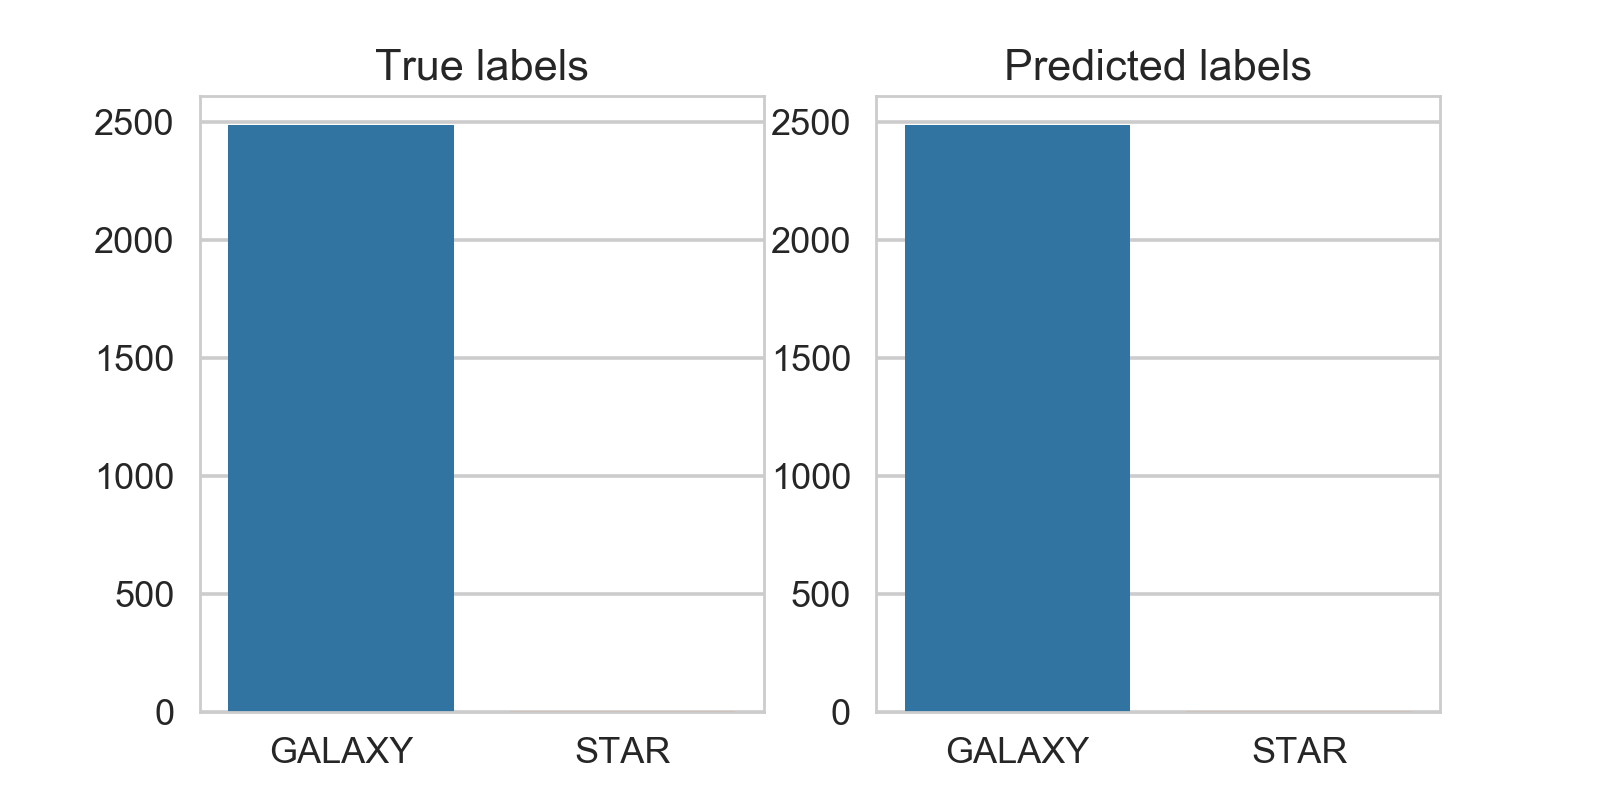

Text(0.5,1,'Predicted labels')

In [437]:
ltest_counts = pd.Series(l_test).value_counts()
ltest_pred_counts = pd.Series(ltest_pred).value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
sns.barplot(ltest_counts.index, ltest_counts.values, ax=ax1)
ax1.set_title("True labels")

sns.barplot(ltest_pred_counts.index, ltest_pred_counts.values, ax=ax2)
ax2.set_title("Predicted labels")

Sigh. KNN works too well for this exercise!

In [438]:
lr = linear_model.LogisticRegression()
lr.fit(X_train, l_train)
print("Training accuracy: " + str(lr.score(X_train, l_train)))
print("Test accuracy: " + str(lr.score(X_test, l_test)))

Training accuracy: 0.996787578637398
Test accuracy: 0.997591328783621


In [439]:
ltest_pred = lr.predict(X_test)
ltrain_pred = lr.predict(X_train)
idx = (ltest_pred != l_test)
ltest_wrong = l_test[idx]
ltest_wrong

9981    STAR
9976    STAR
9987    STAR
9989    STAR
9986    STAR
9977    STAR
Name: class, dtype: object

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


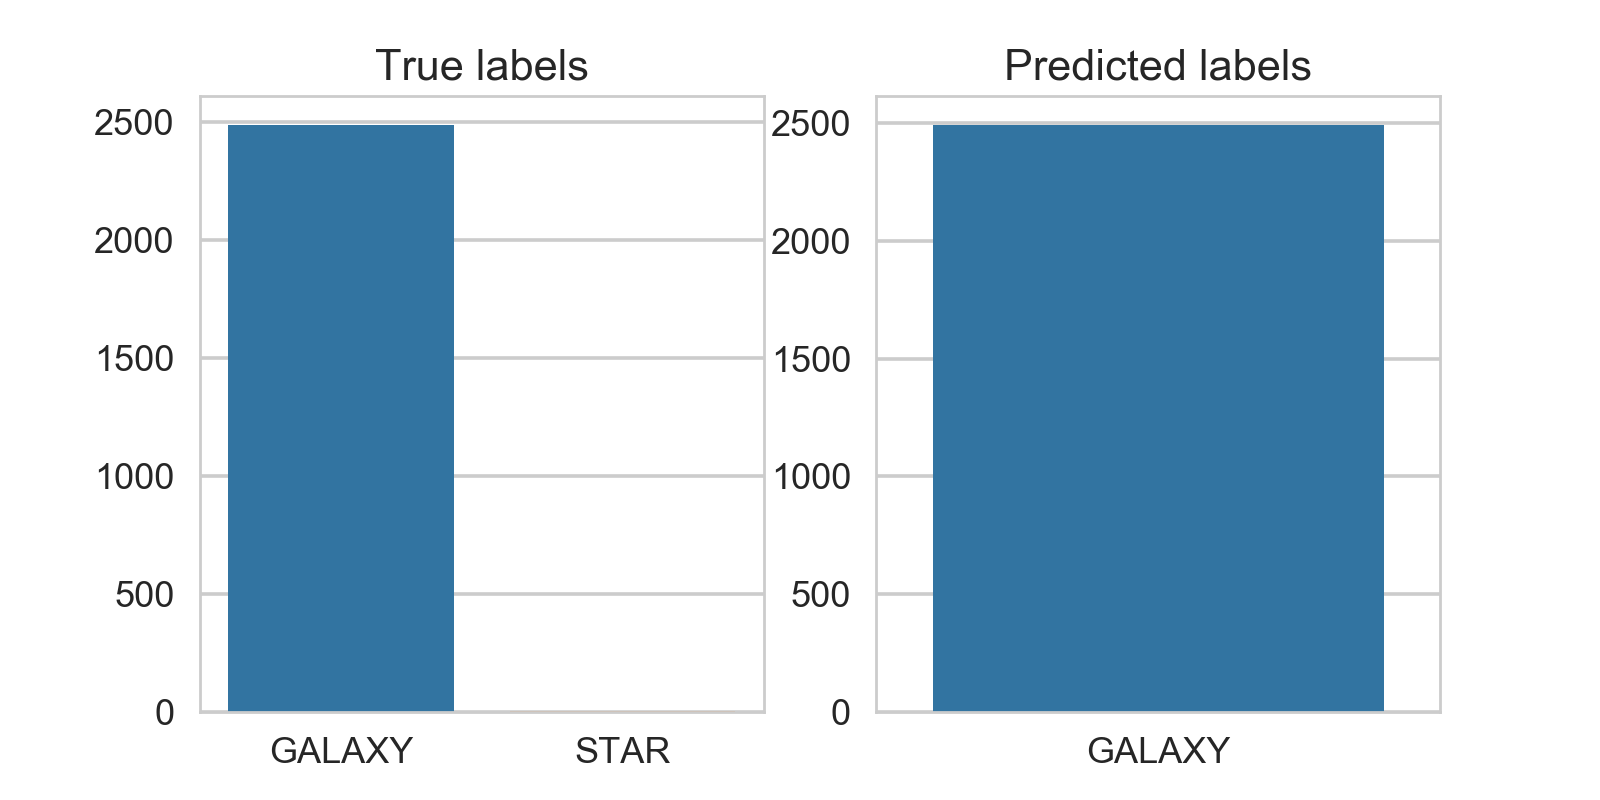

Text(0.5,1,'Predicted labels')

In [440]:
ltest_counts = pd.Series(l_test).value_counts()
ltest_pred_counts = pd.Series(ltest_pred).value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
sns.barplot(ltest_counts.index, ltest_counts.values, ax=ax1)
ax1.set_title("True labels")

sns.barplot(ltest_pred_counts.index, ltest_pred_counts.values, ax=ax2)
ax2.set_title("Predicted labels")

In [441]:
linear_model.LogisticRegression()

LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='ovr', n_jobs=1,
          penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
          verbose=0, warm_start=False)

That still doesn't work properly! 

**Exercise**: Where could you try to improve your classification in order to classify stars correctly? 

**Hint**: One thing you might look at is how many examples of stars actually land in the training/test set (see also the `stratify` keyword in the `train_test_split` function)

**Hint**: Accuracy is just one way to score your results (and as we've shown above, a misleading one). Take a look at the different [evaluation methods](http://scikit-learn.org/stable/modules/model_evaluation.html) and see if there is one that might work better for this classification problem!




Ah, my logistic regression classifier does a worse job. :) 

### Exploring Different Scoring Methods

Note that `accuracy` is just one of several ways you can score your problem. Let's try a different one. For this one, you might want to convert the "STAR" and "GALAXY" labels into numeric labels.

In [442]:
from sklearn.metrics import f1_score

In [443]:
l_test_numeric, l_test_labels = pd.factorize(l_test)

In [444]:
ltest_pred_numeric, ltest_pred_labels = pd.factorize(ltest_pred)

In [445]:
l_test_labels

Index(['GALAXY', 'STAR'], dtype='object')

In [446]:
ltest_pred_labels

array(['GALAXY'], dtype=object)

Let's try the F1 score, a weighted average of [precision and recall](https://en.wikipedia.org/wiki/Precision_and_recall). One advantage this score has is that it has different ways of doing that average. In particular, you can take the unweighted mean for *each label*, which means that in terms of the performance, getting the few stars right is suddenly of equal importance to getting all the galaxies classified correctly. 

In [447]:
f1_score(l_test_numeric, ltest_pred_numeric, average="macro")

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/sklearn/metrics/classification.py:1135: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no predicted samples.
  'precision', 'predicted', average, warn_for)


0.4993971061093247

This score is much worse than the accuracy score, because we haven't classified the stars correctly. Exactly how we wanted! Now we just have to fix it!


**TODO**: Finish this!

## Making Biased Data sets for Redshift Estimation

* hold out faint objects
* hold out bright objects
* hold out weird bits of parameter space
* make one final test set for everyone
* let them compare results and try to figure out what went wrong


In [448]:
qsos = SDSS.query_sql("""SELECT * from (SELECT top 500000
objid, ra, dec, dered_u,dered_g,dered_r,dered_i,dered_z,psfmag_u-extinction_u AS mag_u,
psfmag_g-extinction_g AS mag_g, psfmag_r-extinction_r AS mag_r, psfmag_i-extinction_i AS mag_i,psfmag_z-extinction_z AS mag_z,z AS spec_z,dered_u - dered_g AS u_g_color, 
dered_g - dered_r AS g_r_color,dered_r - dered_i AS r_i_color,dered_i - dered_z AS i_z_color,class
FROM SpecPhoto 
WHERE 
 (class = 'QSO')
 ) as sp
""")

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/astroquery/sdss/core.py:856: VisibleDeprecationWarning: Reading unicode strings without specifying the encoding argument is deprecated. Set the encoding, use None for the system default.
  comments='#'))


In [119]:
qsos = qsos.to_pandas()

In [120]:
len(qsos)

455580

In [121]:
qsos["diff_u"] = qsos["dered_u"] - qsos["mag_u"]
qsos["diff_g"] = qsos["dered_g"] - qsos["mag_g"]
qsos["diff_r"] = qsos["dered_r"] - qsos["mag_r"]
qsos["diff_i"] = qsos["dered_i"] - qsos["mag_i"]
qsos["diff_z"] = qsos["dered_z"] - qsos["mag_z"]

In [122]:
qsos.head()

,objid,ra,dec,dered_u,dered_g,dered_r,dered_i,dered_z,mag_u,mag_g,...,u_g_color,g_r_color,r_i_color,i_z_color,class,diff_u,diff_g,diff_r,diff_i,diff_z
0,1237654668663324688,153.32174,-1.182307,18.55259,18.46902,18.11990,17.73544,17.70927,18.70239,18.69540,...,0.083572,0.349117,0.384455,0.026176,b'QSO',-0.14980,-0.22638,-0.30082,-0.30515,-0.28205
1,1237648720145285290,153.31193,-0.875983,17.73487,17.66219,17.52804,17.55192,17.15414,17.78027,17.76472,...,0.072689,0.134146,-0.023880,0.397783,b'QSO',-0.04540,-0.10253,-0.13777,-0.15940,-0.15213
2,1237650795683184784,146.29180,-0.259474,19.17764,19.03607,18.85442,18.81924,18.42227,19.21860,19.09856,...,0.141571,0.181648,0.035185,0.396971,b'QSO',-0.04096,-0.06249,-0.08403,-0.07973,-0.08514
3,1237650796219924600,145.92530,0.048792,19.05264,19.00238,18.41749,18.22878,17.69278,19.27932,19.33803,...,0.050261,0.584892,0.188707,0.536005,b'QSO',-0.22668,-0.33565,-0.47014,-0.48888,-0.45024
4,1237648721753276447,147.23886,0.373756,18.53681,18.29000,18.20991,18.02177,18.04997,18.57677,18.35021,...,0.246811,0.080084,0.188145,-0.028206,b'QSO',-0.03996,-0.06021,-0.07437,-0.09050,-0.10447


Need to mask out the stupid values:

In [123]:
qsos_clean = qsos.loc[(qsos["mag_u"] > -1000) & (qsos["mag_r"] > -1000) & (qsos["mag_g"] > -1000) & (qsos["mag_i"] > -1000) & (qsos["mag_z"] > -1000)]

In [125]:
len(qsos_clean)

455561

<IPython.core.display.Javascript object>


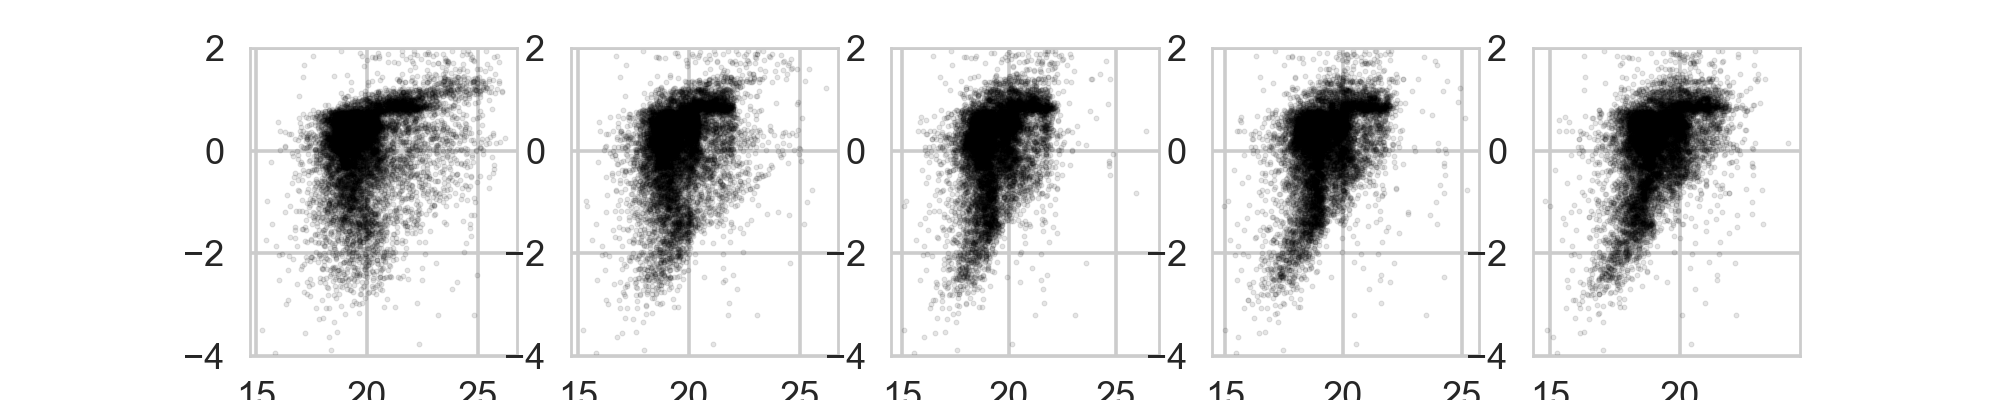

<IPython.core.display.Javascript object>


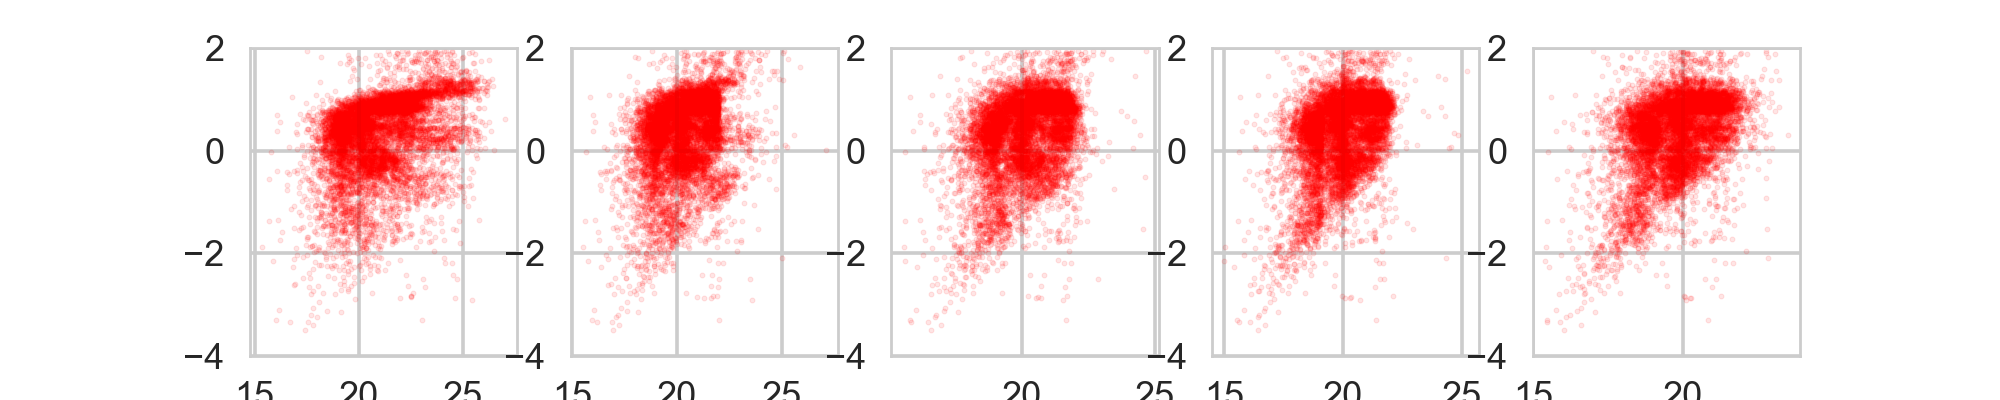

<IPython.core.display.Javascript object>


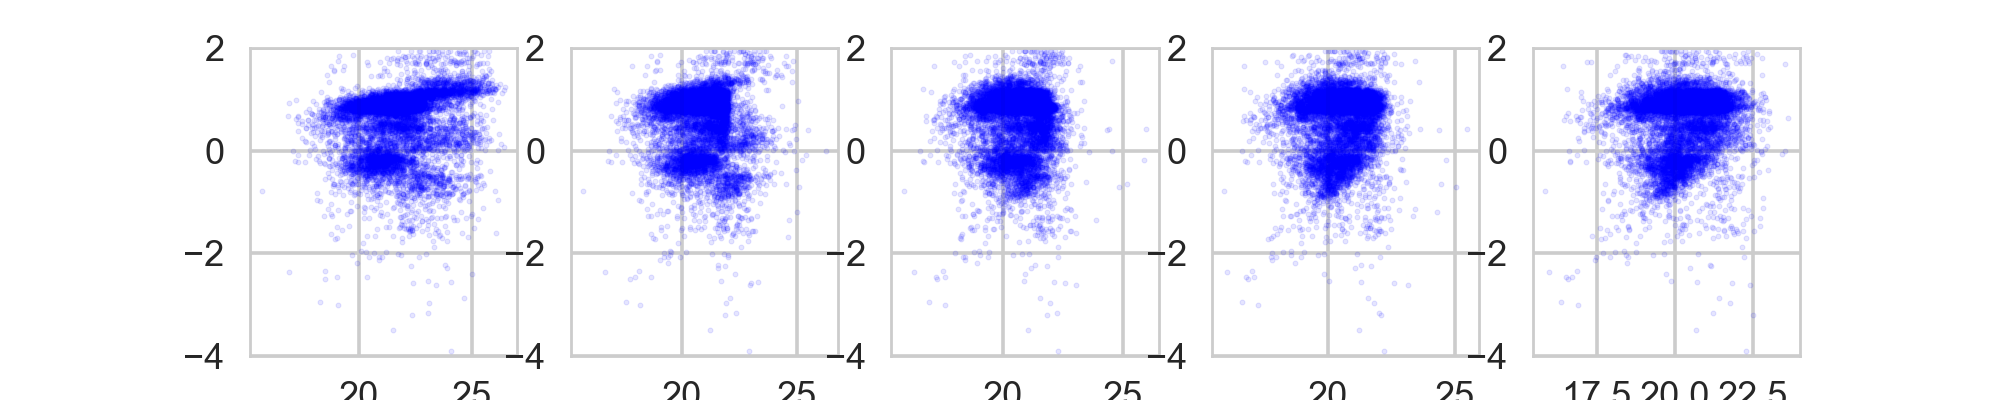

<IPython.core.display.Javascript object>


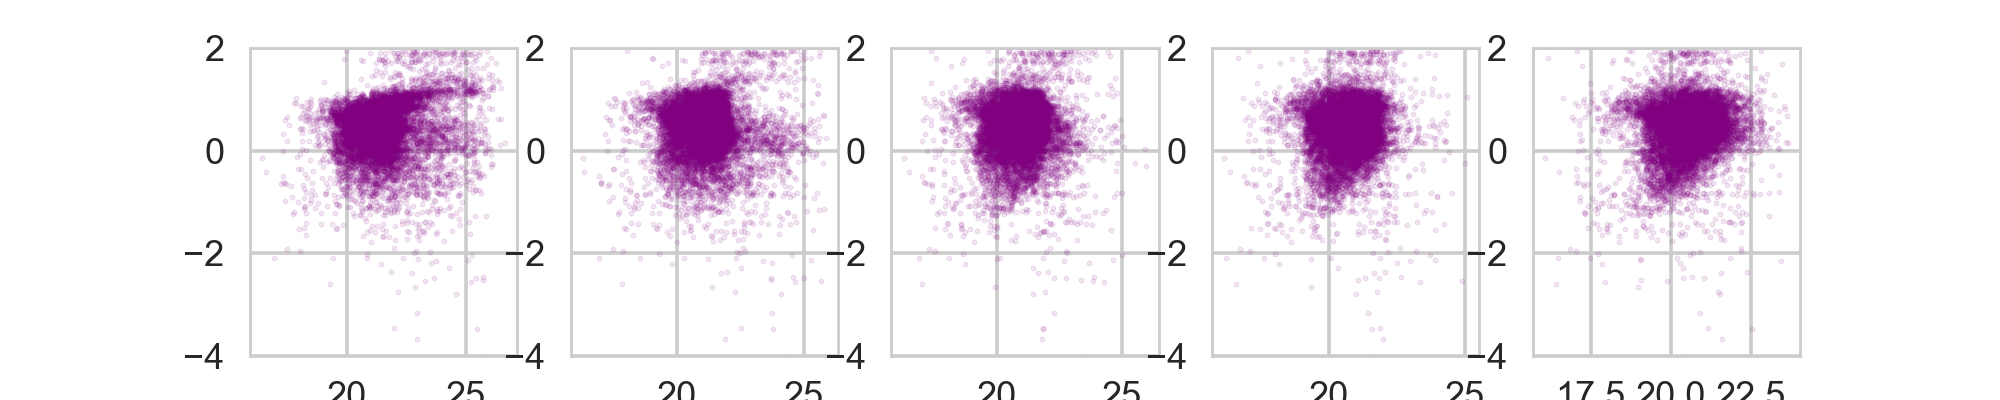

In [154]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i, idx in enumerate(["mag_u", "mag_g", "mag_r", "mag_i", "mag_z"]):
    axes[i].scatter(qsos_clean.loc[qsos_clean.index[:10000], idx], np.log(qsos_clean.loc[qsos_clean.index[:10000], "spec_z"]), s=3, color="black", alpha=0.1)
    axes[i].set_ylim(-4, 2)

fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i, idx in enumerate(["mag_u", "mag_g", "mag_r", "mag_i", "mag_z"]):
    axes[i].scatter(qsos_clean.loc[qsos_clean.index[50000:60000], idx], np.log(qsos_clean.loc[qsos_clean.index[50000:60000], "spec_z"]), s=3, color="red", alpha=0.1)
    axes[i].set_ylim(-4, 2)

fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i, idx in enumerate(["mag_u", "mag_g", "mag_r", "mag_i", "mag_z"]):
    axes[i].scatter(qsos_clean.loc[qsos_clean.index[200000:210000], idx], np.log(qsos_clean.loc[qsos_clean.index[200000:210000], "spec_z"]), s=3, color="blue", alpha=0.1)
    axes[i].set_ylim(-4, 2)

fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i, idx in enumerate(["mag_u", "mag_g", "mag_r", "mag_i", "mag_z"]):
    axes[i].scatter(qsos_clean.loc[qsos_clean.index[-10000:], idx], np.log(qsos_clean.loc[qsos_clean.index[-10000:], "spec_z"]), s=3, color="purple", alpha=0.1)
    axes[i].set_ylim(-4, 2)



### Pull Out a Joint Test Data Set

We're going to pull out a joint test data set for the classification:

In [274]:
indices = np.array(qsos.index)

np.random.seed(20180822)
idx = np.random.choice(indices, size=1000, replace=False)

In [275]:
test_qsos = qsos_clean.loc[idx]

Let's save our test QSOs to file:

In [358]:
test_qsos.to_csv("sdss_test_qsos.csv")

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


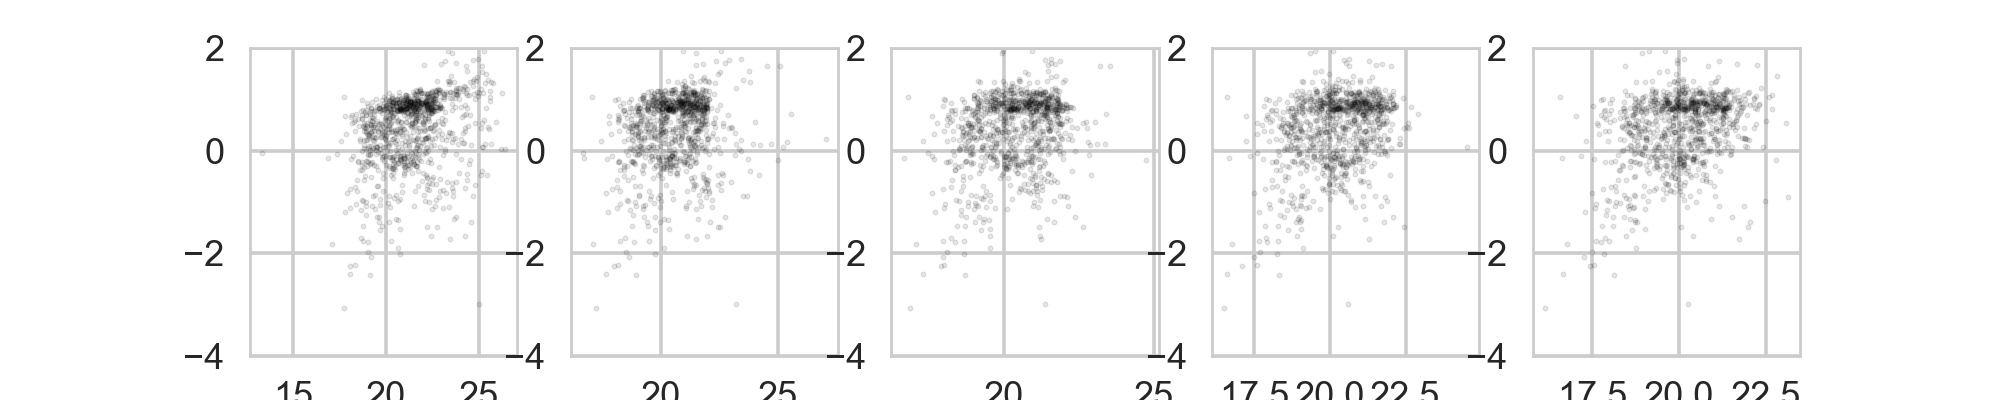

In [276]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i, m in enumerate(["mag_u", "mag_g", "mag_r", "mag_i", "mag_z"]):
    axes[i].scatter(test_qsos[m], np.log(test_qsos["spec_z"]), s=3, color="black", alpha=0.1)
    axes[i].set_ylim(-4, 2)

In [280]:
indices = qsos.index.drop(idx)

In [281]:
qsos_train = qsos.loc[indices]

In [282]:
len(qsos_train)

454580

In [284]:
sdss_dataset2 = qsos_train.loc[qsos_train.index[:10000]]

In [285]:
mask = ((sdss_dataset2["mag_u"] < -1000) | (sdss_dataset2["mag_g"] < -1000) | (sdss_dataset2["mag_r"] < -1000) | (sdss_dataset2["mag_i"] < -1000) | (sdss_dataset2["mag_z"] < -1000) )

In [287]:
len(sdss_dataset2[mask])

3

In [288]:
sdss_dataset3 = qsos_train.loc[qsos_train.index[50000:59997]]

In [289]:
sdss_dataset4 = qsos_train.loc[qsos_train.index[200000:209997]]

In [290]:
sdss_dataset5 = qsos_train.loc[qsos_train.index[-9997:]]

In [291]:
sdss_dataset3 = pd.concat([sdss_dataset3, sdss_dataset2[mask]])
sdss_dataset4 = pd.concat([sdss_dataset4, sdss_dataset2[mask]])
sdss_dataset5 = pd.concat([sdss_dataset5, sdss_dataset2[mask]])

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


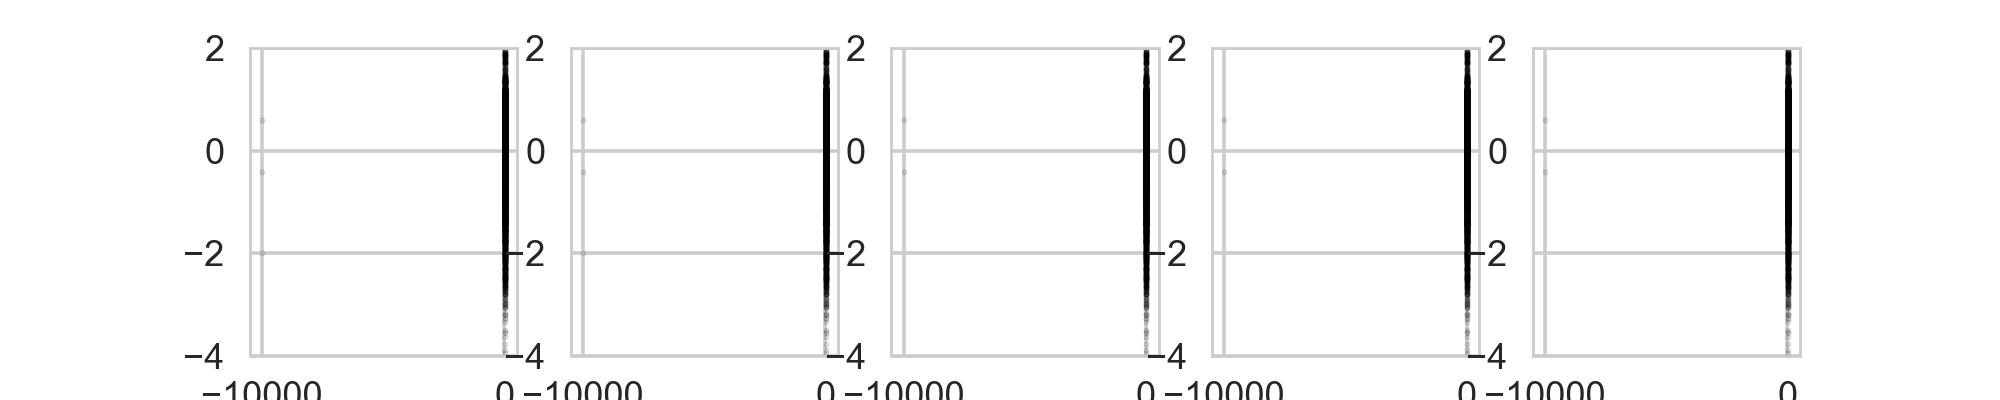

<IPython.core.display.Javascript object>


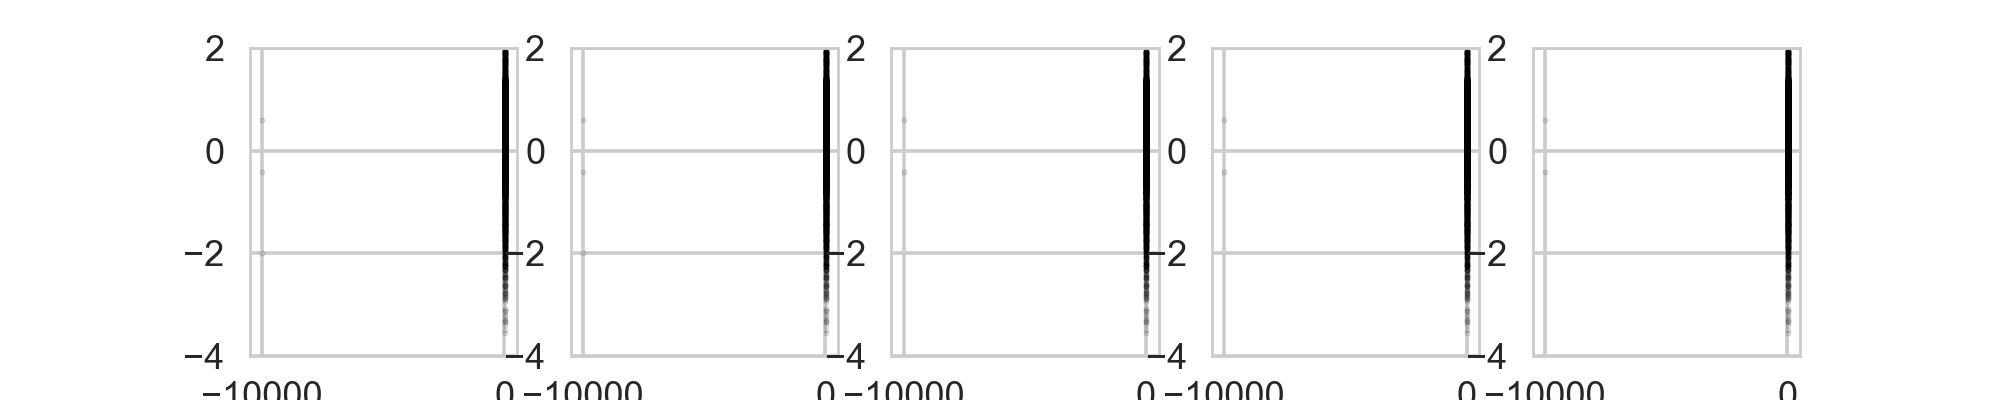

<IPython.core.display.Javascript object>


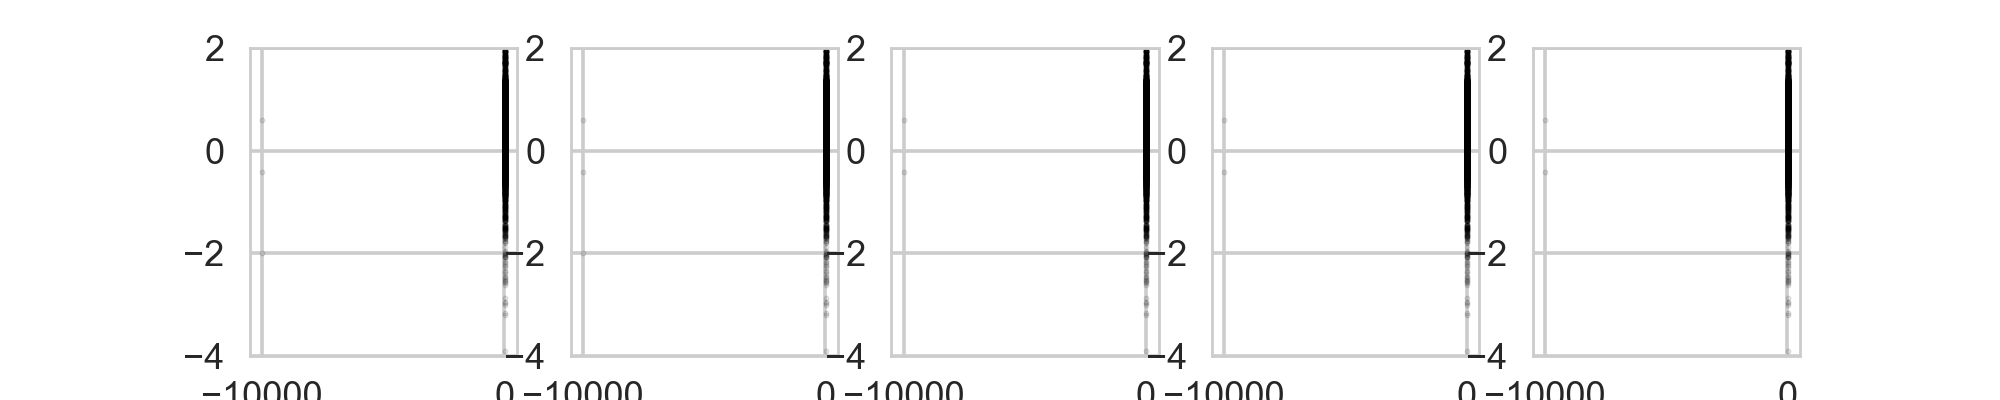

<IPython.core.display.Javascript object>


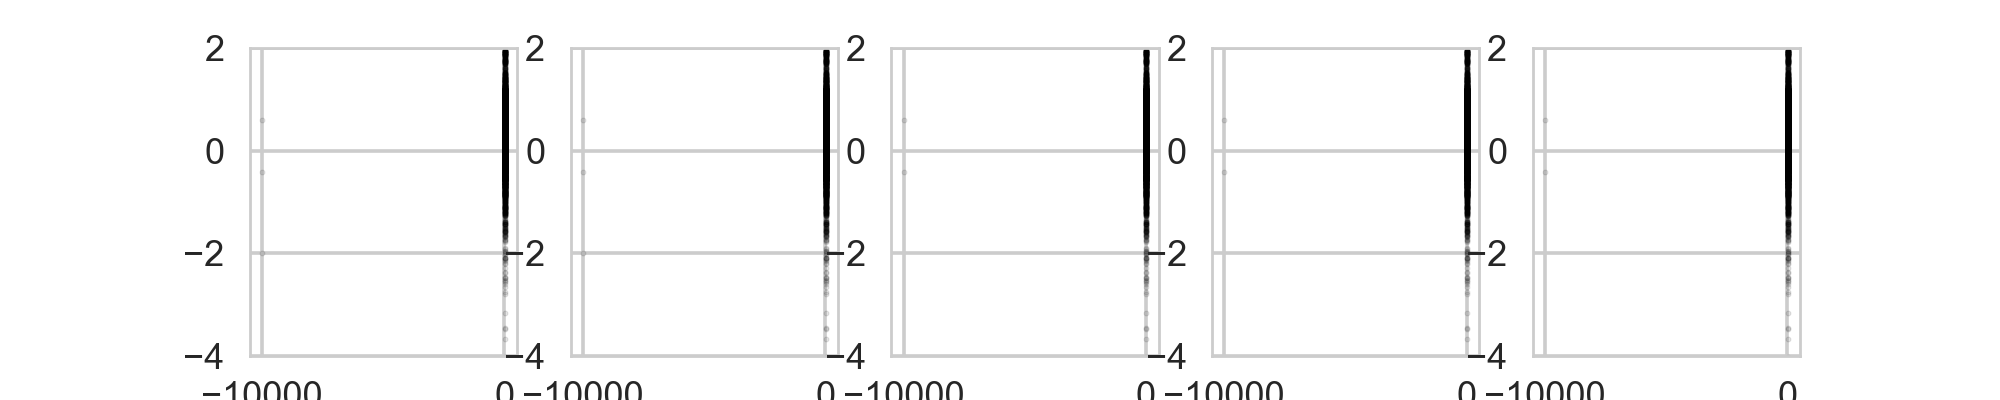

In [292]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i, idx in enumerate(["mag_u", "mag_g", "mag_r", "mag_i", "mag_z"]):
    axes[i].scatter(sdss_dataset2[idx], np.log(sdss_dataset2["spec_z"]), s=3, color="black", alpha=0.1)
    axes[i].set_ylim(-4, 2)

fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i, idx in enumerate(["mag_u", "mag_g", "mag_r", "mag_i", "mag_z"]):
    axes[i].scatter(sdss_dataset3[idx], np.log(sdss_dataset3["spec_z"]), s=3, color="black", alpha=0.1)

    axes[i].set_ylim(-4, 2)

fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i, idx in enumerate(["mag_u", "mag_g", "mag_r", "mag_i", "mag_z"]):
    axes[i].scatter(sdss_dataset4[idx], np.log(sdss_dataset4["spec_z"]), s=3, color="black", alpha=0.1)

    axes[i].set_ylim(-4, 2)

fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i, idx in enumerate(["mag_u", "mag_g", "mag_r", "mag_i", "mag_z"]):
    axes[i].scatter(sdss_dataset5[idx], np.log(sdss_dataset5["spec_z"]), s=3, color="black", alpha=0.1)

    axes[i].set_ylim(-4, 2)



In [293]:
sdss_dataset2.to_csv("sdss_dataset2.csv")
sdss_dataset3.to_csv("sdss_dataset3.csv")
sdss_dataset4.to_csv("sdss_dataset4.csv")
sdss_dataset5.to_csv("sdss_dataset5.csv")

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


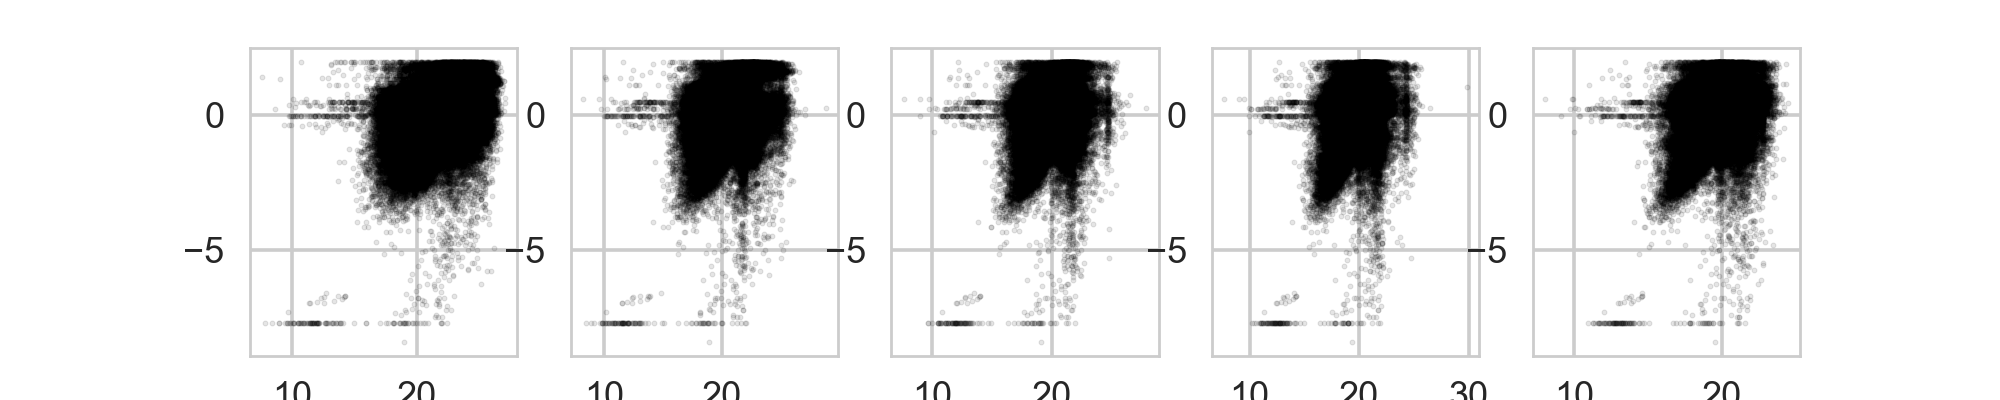

In [294]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i, idx in enumerate(["mag_u", "mag_g", "mag_r", "mag_i", "mag_z"]):
    axes[i].scatter(qsos_clean[idx], np.log(qsos_clean["spec_z"]), s=3, color="black", alpha=0.1)

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


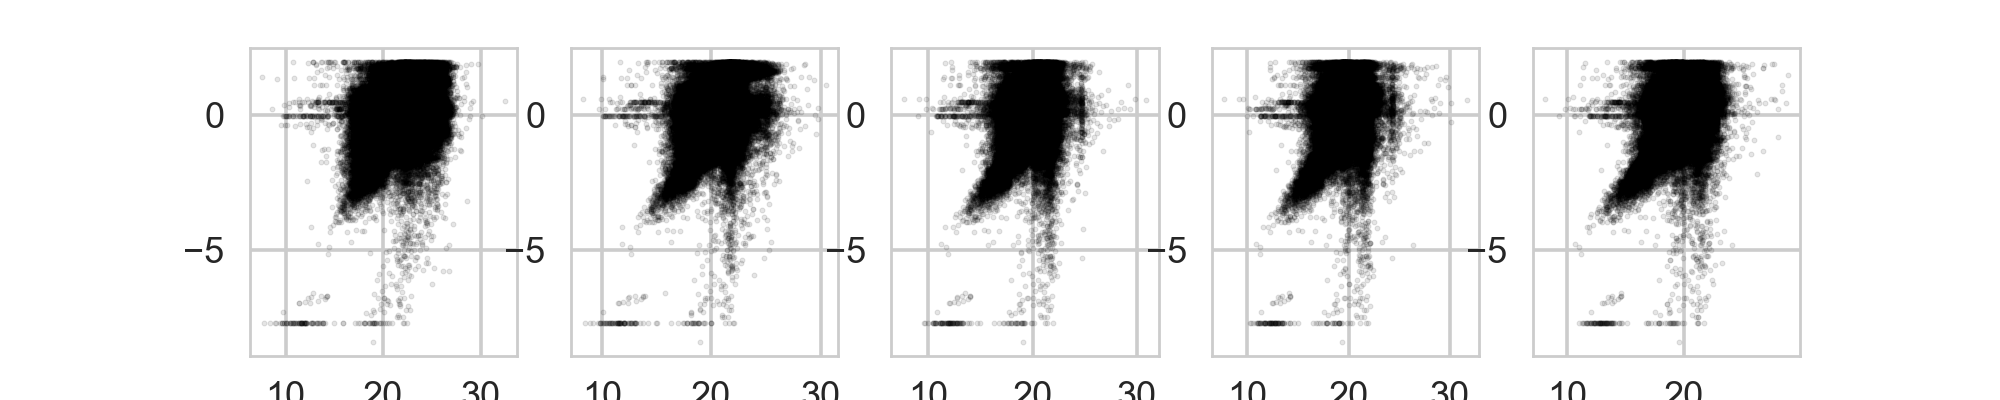

In [295]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i, idx in enumerate(["dered_u", "dered_g", "dered_r", "dered_i", "dered_z"]):
    axes[i].scatter(qsos_clean[idx], np.log(qsos_clean["spec_z"]), s=3, color="black", alpha=0.1)

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


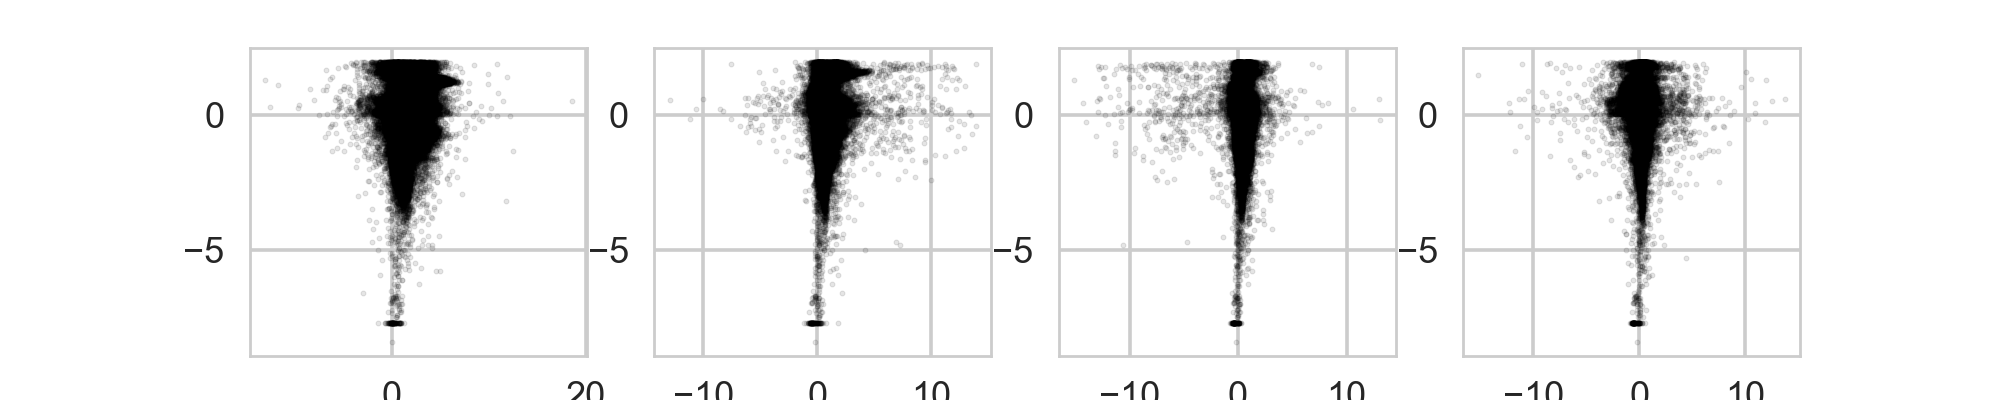

In [200]:
fig, axes = plt.subplots(1, 4, figsize=(10, 2))

for i, idx in enumerate(["u_g_color", "g_r_color", "r_i_color", "i_z_color"]):
    axes[i].scatter(qsos_clean[idx], np.log(qsos_clean["spec_z"]), s=3, color="black", alpha=0.1)

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


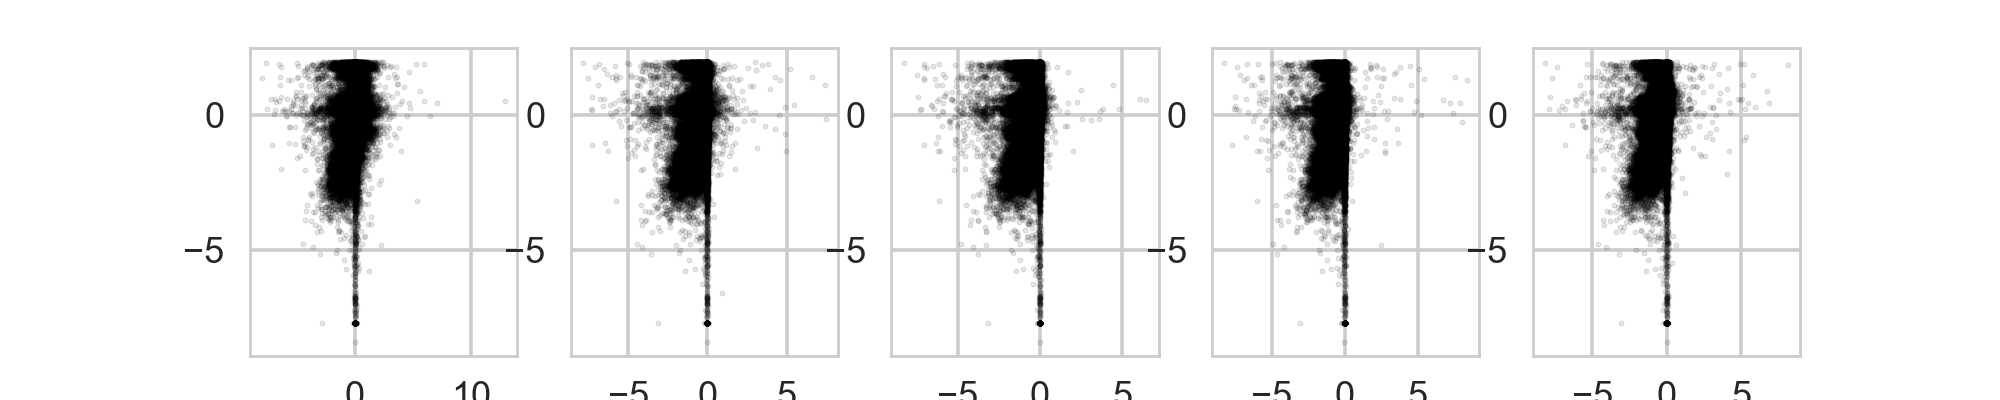

In [296]:
fig, axes = plt.subplots(1, 5, figsize=(10, 2))

for i, idx in enumerate(["diff_u", "diff_g", "diff_r", "diff_i", "diff_z"]):
    axes[i].scatter(qsos_clean[idx], np.log(qsos_clean["spec_z"]), s=3, color="black", alpha=0.1)

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


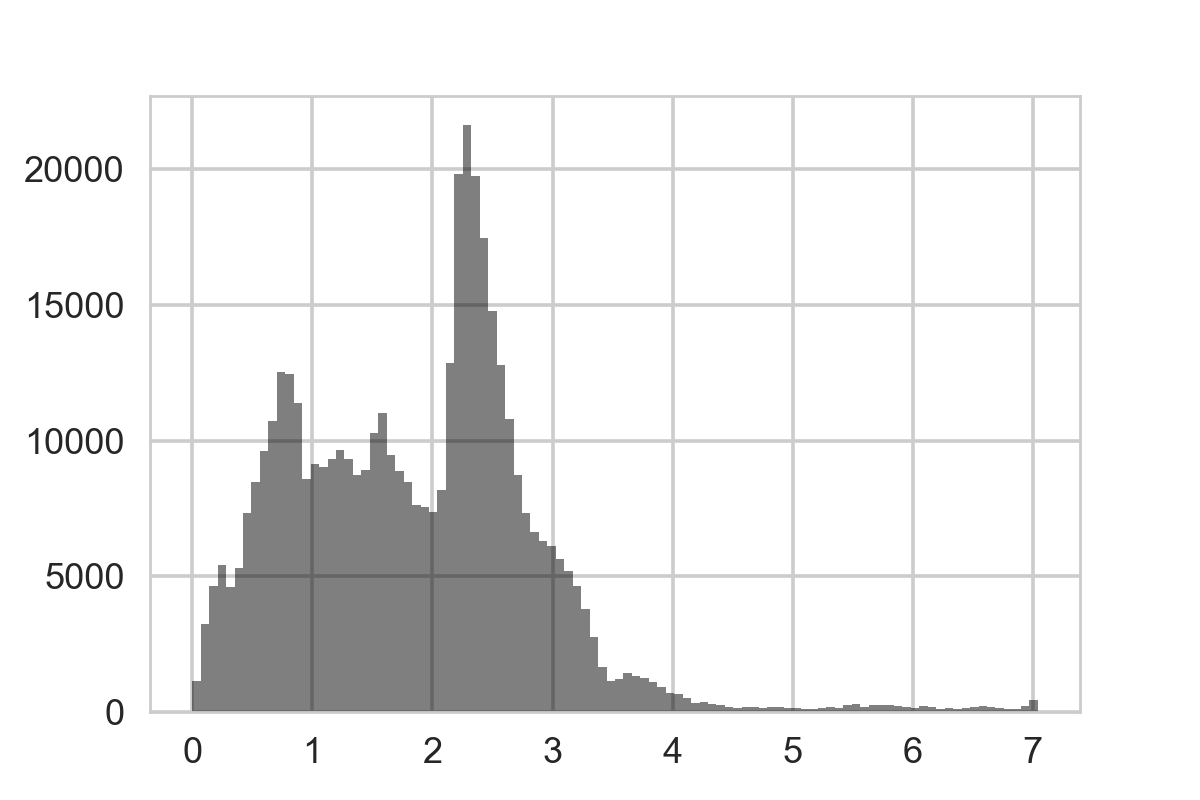

In [297]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.hist(qsos["spec_z"], bins=100, alpha=0.5, color="black", histtype="stepfilled");

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


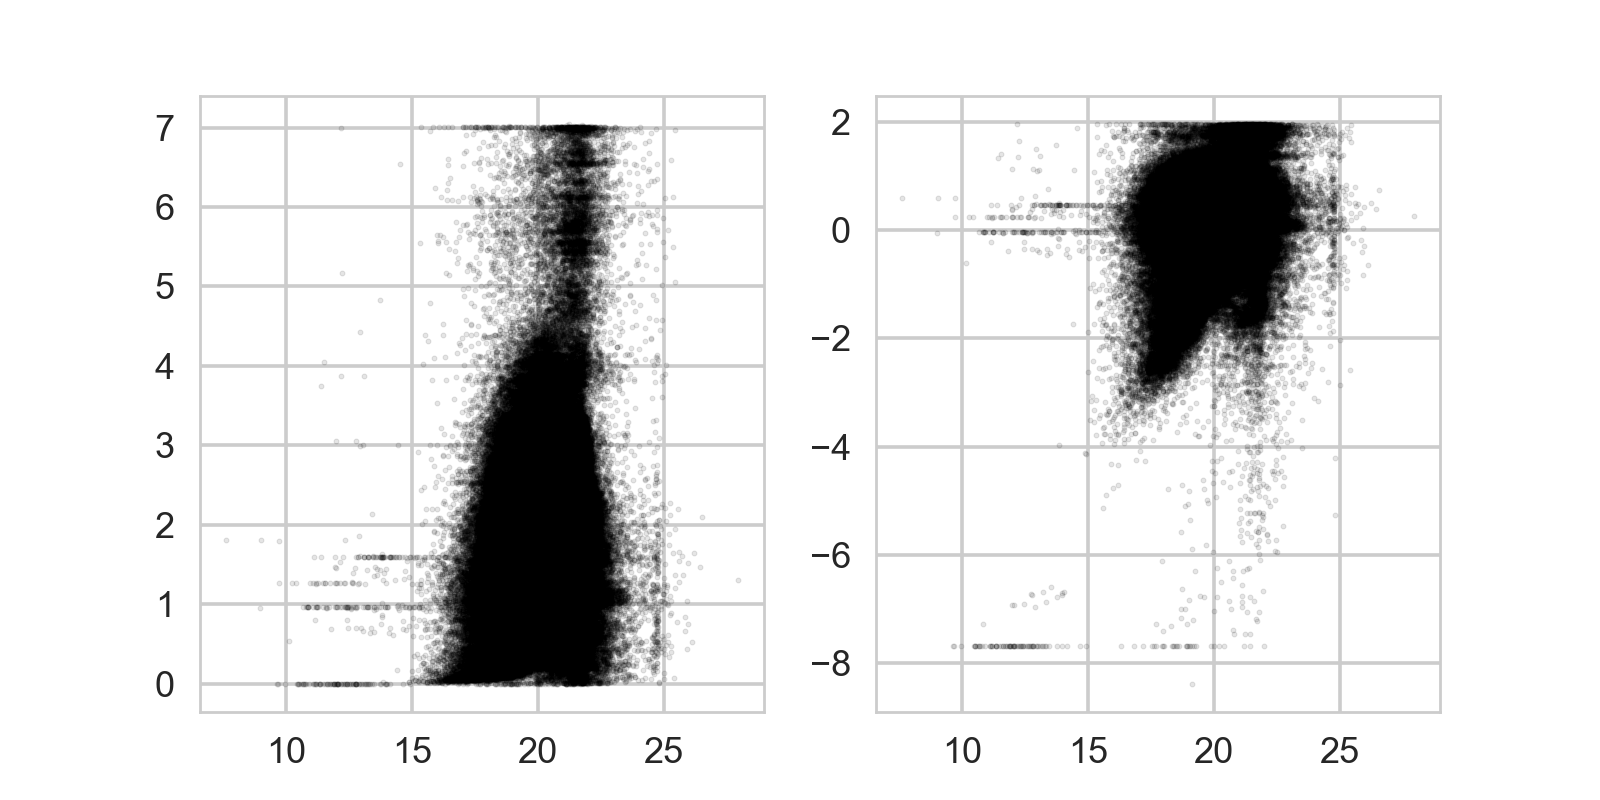

In [298]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))

ax1.scatter(qsos_clean["mag_r"], qsos_clean["spec_z"], s=3, color="black", alpha=0.1)
ax2.scatter(qsos_clean["mag_r"], np.log(qsos_clean["spec_z"]), s=3, color="black", alpha=0.1)

### Data Set 6: remove all redshifts > 4.5


In [299]:
mask = (qsos_train["spec_z"] < 4.5)

In [300]:
qsos1 = qsos_train[mask]

In [302]:
indices = np.array(qsos1.index)

In [303]:
np.random.seed(1000)
idx = np.random.choice(indices, size=10000, replace=False)

In [304]:
idx

array([253381, 222232, 323709, ..., 289731,  19882, 111193])

In [305]:
qsos1 = qsos1.loc[idx, :]

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


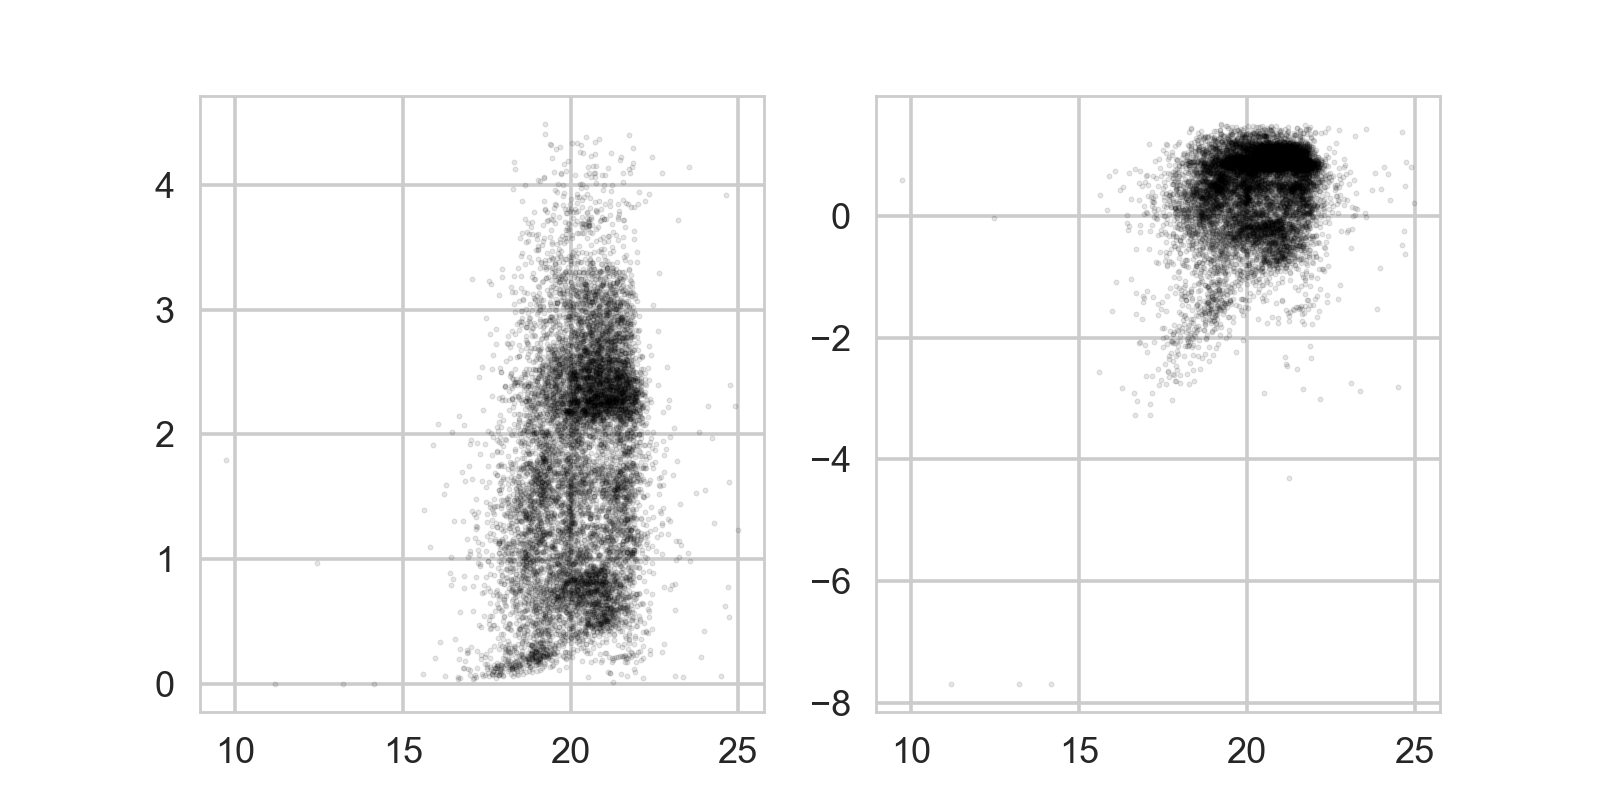

In [308]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))

ax1.scatter(qsos1["mag_r"], qsos1["spec_z"], s=3, color="black", alpha=0.1)
ax2.scatter(qsos1["mag_r"], np.log(qsos1["spec_z"]), s=3, color="black", alpha=0.1)

In [306]:
len(qsos1)

10000

In [307]:
qsos1.to_csv("sdss_dataset6.csv")

### Data Set 7: Remove everything with r-band magnitude > 19

In [333]:
mask = (qsos_train["mag_r"] < 19)

In [339]:
qsos2 = qsos_train[mask]

In [341]:
indices = np.array(qsos2.index)
np.random.seed(2000)
idx = np.random.choice(indices, size=10000, replace=False)

In [342]:
print(idx)

[  7725 426174   6218 ... 300648 323700 116520]


In [343]:
qsos2 = qsos2.loc[idx]

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


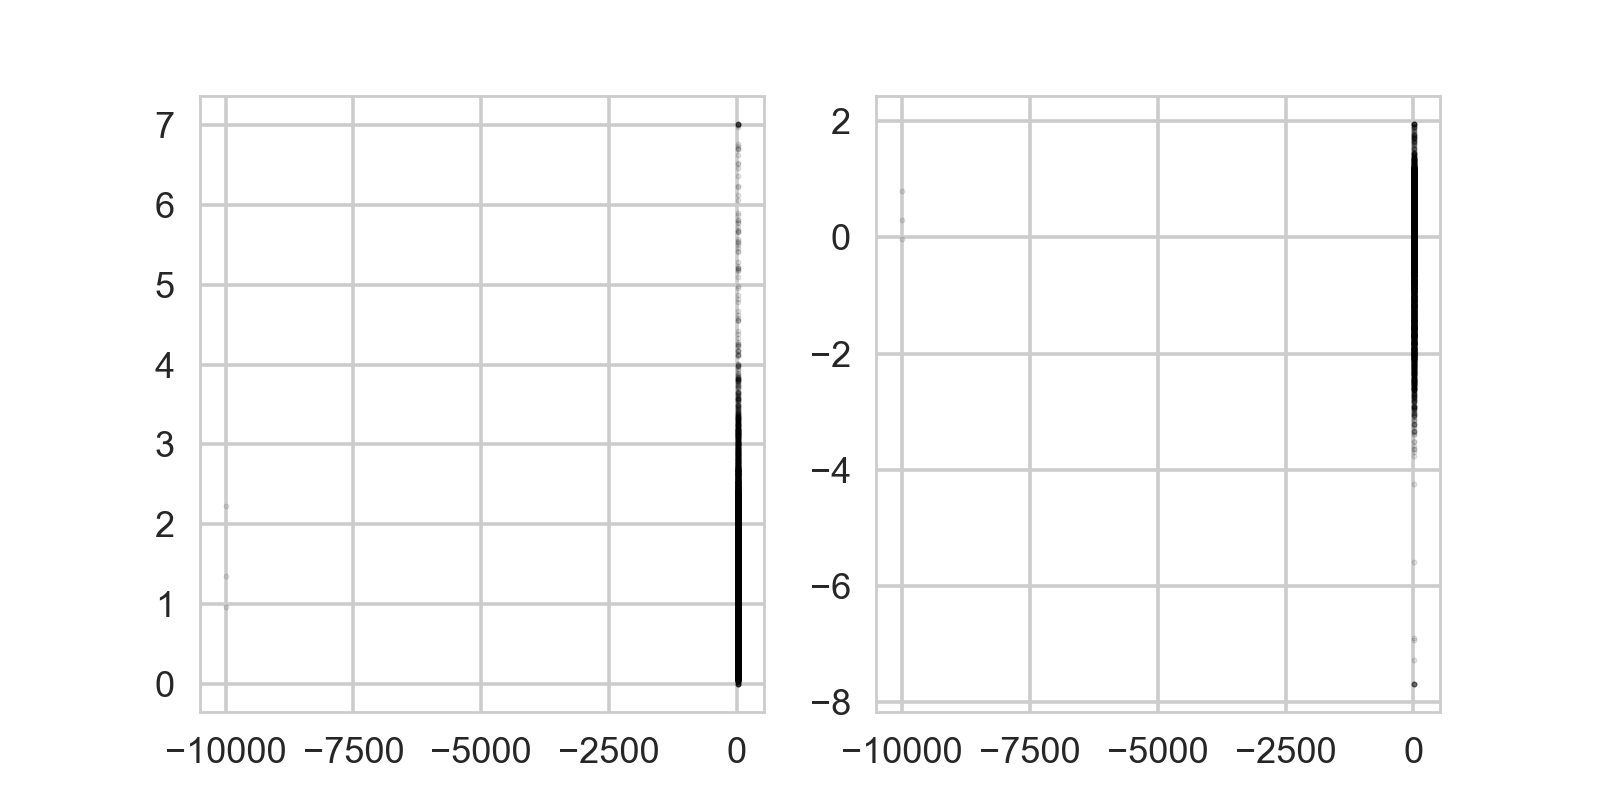

In [344]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))

ax1.scatter(qsos2["mag_r"], qsos2["spec_z"], s=3, color="black", alpha=0.1)
ax2.scatter(qsos2["mag_r"], np.log(qsos2["spec_z"]), s=3, color="black", alpha=0.1)

In [345]:
qsos2.to_csv("sdss_dataset7.csv")

### Data set 8: Remove everything smaller than redshift 0.4

In [346]:
mask = (qsos_train["spec_z"] > 0.4)

In [347]:
qsos3 = qsos_train[mask]

In [348]:
indices = np.array(qsos3.index)
np.random.seed(3000)
idx = np.random.choice(indices, size=10000, replace=False)

In [349]:
qsos3 = qsos3.loc[idx]

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


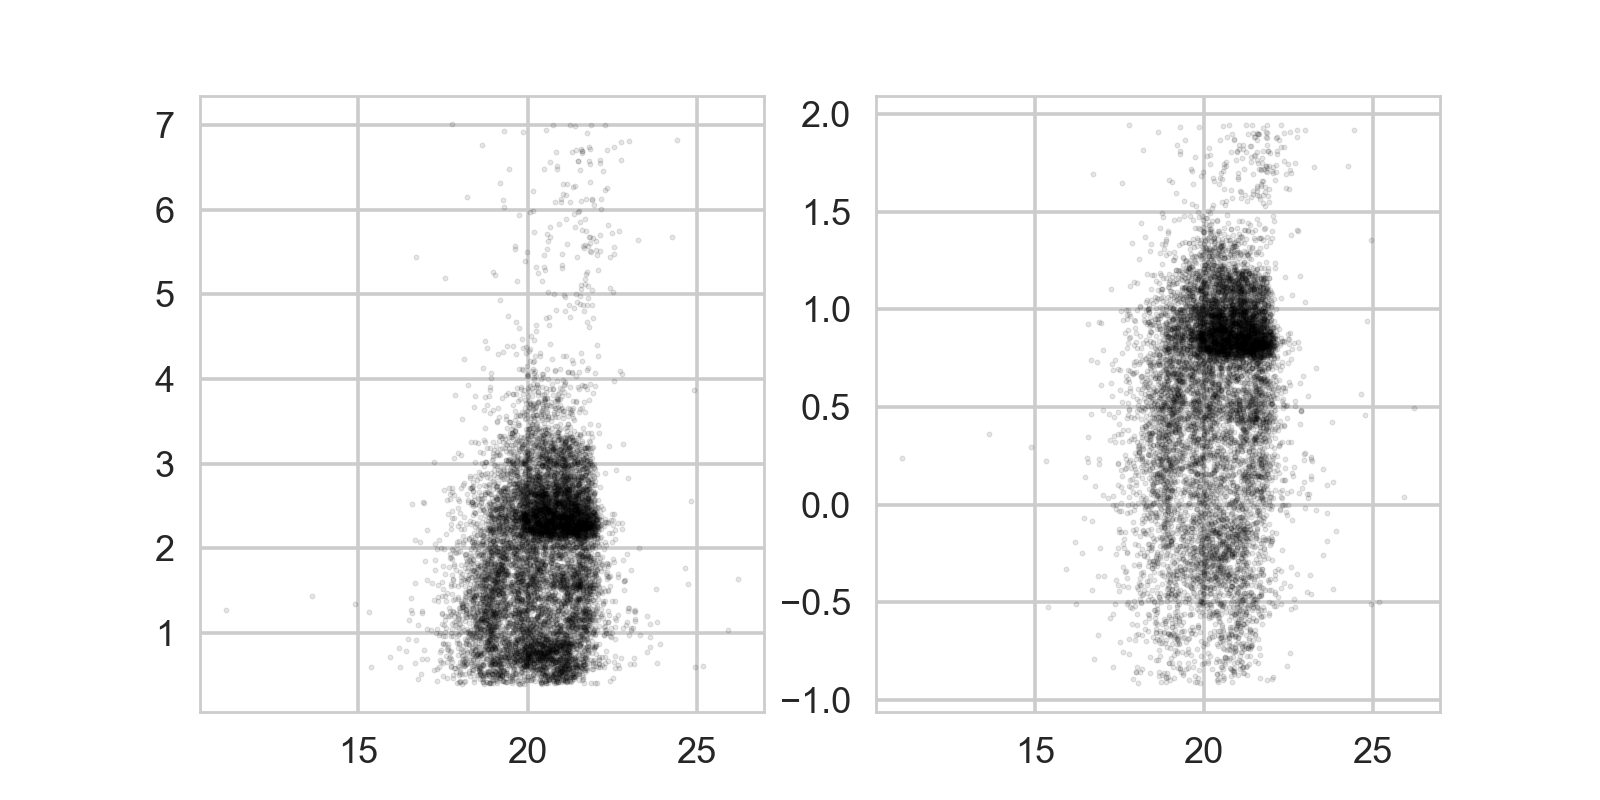

In [350]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))

ax1.scatter(qsos3["mag_r"], qsos3["spec_z"], s=3, color="black", alpha=0.1)
ax2.scatter(qsos3["mag_r"], np.log(qsos3["spec_z"]), s=3, color="black", alpha=0.1)

In [351]:
qsos3.to_csv("sdss_dataset8.csv")

### Data Set 4: Remove everything with de-reddened z-magnitude < 16

In [352]:
mask = (qsos_train["dered_z"] > 16.5)

In [353]:
qsos4 = qsos_train[mask]

In [354]:
indices = np.array(qsos4.index)
np.random.seed(4000)
idx = np.random.choice(indices, size=10000, replace=False)

In [355]:
qsos4 = qsos4.loc[idx]

/Users/danielahuppenkothen/work/sw/miniconda3/lib/python3.6/site-packages/matplotlib/pyplot.py:537: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


<IPython.core.display.Javascript object>


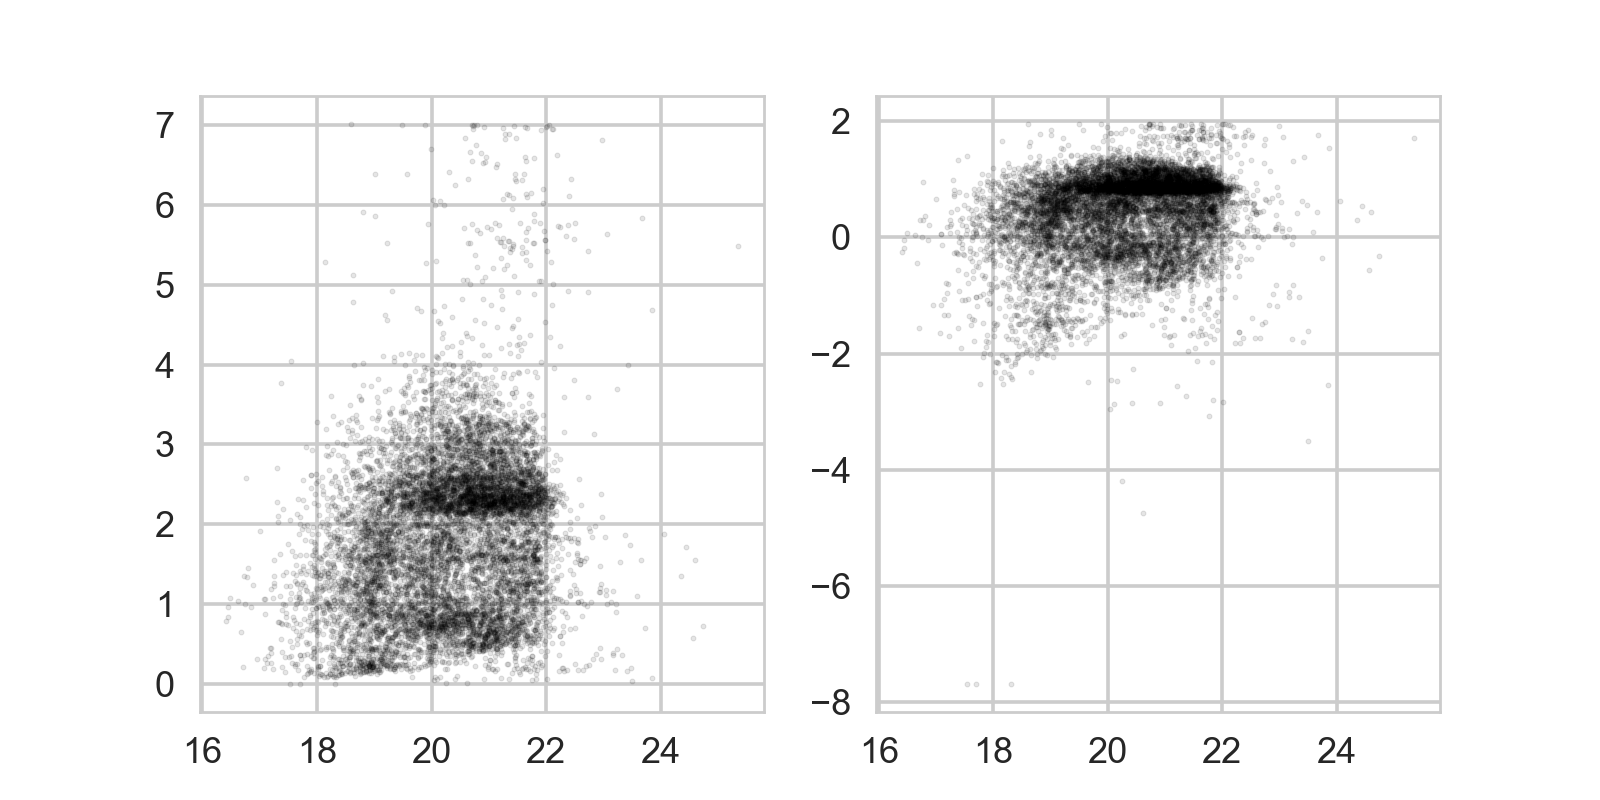

In [356]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))

ax1.scatter(qsos4["mag_r"], qsos4["spec_z"], s=3, color="black", alpha=0.1)
ax2.scatter(qsos4["mag_r"], np.log(qsos4["spec_z"]), s=3, color="black", alpha=0.1)

In [357]:
qsos4.to_csv("sdss_dataset9.csv")

# Some machine learning with SDSS data

I decided to follow parts of a [previous AstroHackWeek demo](https://github.com/AstroHackWeek/AstroHackWeek2016/blob/master/day2-machine-learning/machine-learning-on-SDSS.ipynb) by J. S. Bloom (2014, 2016).

This workbook is for a discussion about starting out with ML methods, but the results we get are problematic from a physics perspective for multiple reasons (some of which we discuss).

We're going to use data from the [SDSS skyserver SQL server](http://skyserver.sdss3.org/public/en/tools/search/sql.aspx). For more information on this data I found a [terse description of the fields in the table](http://skyserver.sdss.org/dr14/en/help/browser/browser.aspx#&&history=description+SpecPhoto+V
) and [some details of the preprocessing](http://skyserver.sdss.org/dr1/en/help/docs/algorithm.asp). An example query (you won't have to do this yourself) to get two types of photometry (aperature and petrosian), corrected for extinction, for 1000 QSO sources with redshifts:

```
SELECT *,dered_u - mag_u AS diff_u, dered_g - mag_g AS diff_g, dered_r - mag_r AS diff_g, dered_i - mag_i AS diff_i, dered_z - mag_z AS diff_z from
(SELECT top 1000
objid, ra, dec, dered_u,dered_g,dered_r,dered_i,dered_z,psfmag_u-extinction_u AS mag_u,
psfmag_g-extinction_g AS mag_g, psfmag_r-extinction_r AS mag_r, psfmag_i-extinction_i AS mag_i,psfmag_z-extinction_z AS mag_z,z AS spec_z,dered_u - dered_g AS u_g_color, 
dered_g - dered_r AS g_r_color,dered_r - dered_i AS r_i_color,dered_i - dered_z AS i_z_color,class
FROM SpecPhoto 
WHERE 
 (class = 'QSO')
 ) as sp
```

J. S. Bloom already ran some queries like this and saved them as `csv`, and removed the first line containing `#Table` from the file. The next cell will download one of these files, with data from 10,000 QSO sources:

In [22]:
import os
if os.path.exists('qso10000.csv'):
    print('Have already downloaded data.')
else:
    os.system('wget https://gist.githubusercontent.com/anonymous/53781fe86383c435ff10/raw/4cc80a638e8e083775caec3005ae2feaf92b8d5b/qso10000.csv')

Have already downloaded data.


## First look at the data

In [23]:
import pandas as pd
pd.set_option('display.max_columns', None)

qso = pd.read_csv('qso10000.csv', index_col=0)
print(qso.columns) # to see all column names without scrolling before looking at sample of table
qso.head()

Index(['ra', 'dec', 'dered_u', 'dered_g', 'dered_r', 'dered_i', 'dered_z',
       'mag_u', 'mag_g', 'mag_r', 'mag_i', 'mag_z', 'spec_z', 'u_g_color',
       'g_r_color', 'r_i_color', 'i_z_color', 'class', 'diff_u', 'diff_g',
       'diff_g1', 'diff_i', 'diff_z'],
      dtype='object')


,ra,dec,dered_u,dered_g,dered_r,dered_i,dered_z,mag_u,mag_g,mag_r,mag_i,mag_z,spec_z,u_g_color,g_r_color,r_i_color,i_z_color,class,diff_u,diff_g,diff_g1,diff_i,diff_z
objid,,,,,,,,,,,,,,,,,,,,,,,
1237648720142532813,146.90229,-0.984913,19.64289,19.31131,19.25328,19.15353,19.13345,19.71604,19.37595,19.32818,19.24847,19.21259,0.652417,0.331583,0.058027,0.099751,0.020077,QSO,-0.073151,-0.064648,-0.074903,-0.094942,-0.079136
1237658425156829371,142.45853,6.646406,19.39569,19.34811,19.16626,18.93152,19.06013,19.40327,19.36566,19.18335,18.94222,19.08077,1.537123,0.047575,0.181847,0.234743,-0.128612,QSO,-0.007589,-0.017550,-0.017090,-0.010700,-0.020636
1237660413189095710,143.15770,8.175363,19.10362,18.88904,18.70672,18.58508,18.61328,19.11102,18.88857,18.70458,18.57886,18.62583,1.467101,0.214582,0.182318,0.121645,-0.028202,QSO,-0.007397,0.000473,0.002148,0.006218,-0.012548
1237660412651962520,142.49264,7.800945,19.88820,19.75146,19.52941,19.65000,19.52470,19.88709,19.75292,19.53512,19.67052,19.50256,1.014217,0.136745,0.222052,-0.120590,0.125301,QSO,0.001118,-0.001457,-0.005716,-0.020527,0.022139
1237658493336944662,142.64367,7.917698,18.45897,18.40651,18.15901,17.77130,17.75986,18.55725,18.55002,18.40316,18.01008,18.03100,0.215603,0.052462,0.247498,0.387709,0.011444,QSO,-0.098282,-0.143515,-0.244150,-0.238779,-0.271137


**We'll be predicting redshift 'spec_z' from the photometry data.**

Following Bloom we'll end up dropping the position on the sky 'ra' and 'dec'.

If we're interested in the relationship between photometry and redshift, the location on the sky shouldn't be relevant. Except that if the corrections to contamination that varies of the sky hasn't been done properly, there could be "signal" there. Seeing if an ML method can do something with 'ra' and 'dec' might be interesting for detecting problems in the data. But for now, we'll assume that's not what we want to do.

But before discarding 'ra' and 'dec', we'll make a quick plot of the 'ra' values in the order they appear in the table:

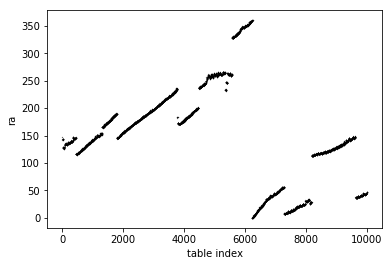

In [24]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(qso['ra'].values, 'k.', ms=0.5)
plt.xlabel('table index'); plt.ylabel('ra');

The data is not in a random order. If first learning about machine learning and trying out methods, my recommendation is to default to using randomly shuffled data. A good default for some machine learning methods (e.g., when using mini-batch optimizers for neural networks) is to use random examples. Also, when we later split the data into train/validation/test sets, we may want the training set 'ra' values to be representative of what we'll see in 'future' at validation time. Again, *if we're first doing machine learning*, having the validation and testing sets come from different distributions adds a complication we probably want to avoid.

However, if we were interested in seeing how well a system could forecast into the future, we may want to take the validation and test sets from the end of a dataset (if gathered as a time series). So we would split up the data into train/validation/test before shuffling the training set.

In this example, we do *not* have a representative sample of the SDSS data! If you download the data for 500,000 QSO sources and rerun this notebook, you'll find that the validation performance gets a lot worse, far outside our error bars :-(. So really we want to shuffle all of SDSS's data before subsampling and splitting, rather than shuffling within the top 10,000 results that SDSS returned.

When I shuffle the data I clamp the random seed to make this study reproducible and stable. Normally I would put data selection in a separate file and save out the results. My analysis code would then definitely load the same data every time. If we wanted to see the sensitivity of methods to dataset choice, we could change the seed.

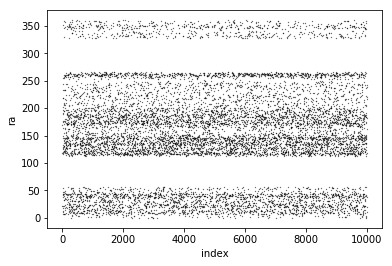

In [25]:
import numpy as np
qso = qso.iloc[np.random.RandomState(seed=12345).permutation(len(qso))]
plt.plot(qso['ra'].values, 'k.', ms=0.5)
plt.xlabel('index'); plt.ylabel('ra');

## Setting up the output to predict

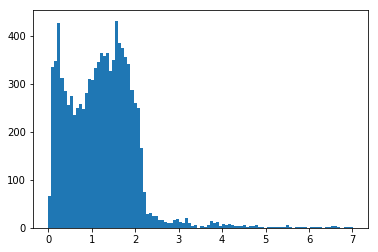

In [26]:
# We want to predict redshifts:
plt.hist(qso['spec_z'], 100, histtype='stepfilled');

My knee-jerk reaction for a quantity that's positive, skewed, and has a big range, is to take logs. It's not always the right thing to do, but is often a good idea.

Taking logs of the output means the machine learning method cares about relative errors in its predictions rather than absolute red-shifts. I'll let the astronomers decide if that makes sense...

If you're not sure whether to take the log of an input, you can always add both the original feature and its transformed version to your table. Let the machine learning method decide how to use them!

In [27]:
# If you download more data some redshifts can be -ve!
# For example, Andromeda is moving towards us.
# I hackily make all the numbers +ve so I can take logs.
if qso['spec_z'].min() < 0:
    qso['spec_z'] += 2*abs(qso['spec_z'].min())

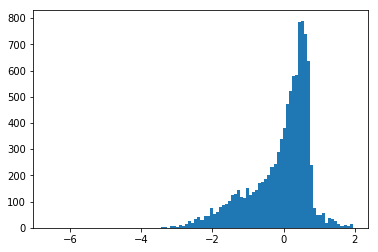

In [28]:
# Or maybe *log* redshifts...
import numpy as np
qso_y = np.log(qso['spec_z'])
plt.hist(qso_y, 100, histtype='stepfilled');

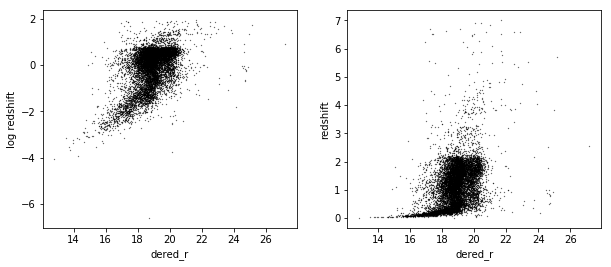

In [29]:
mask = qso['dered_r'] > -9000  # we'll see why shortly...
plt.figure(figsize=[10, 4]);
plt.subplot(1, 2, 1); plt.plot(qso['dered_r'][mask], qso_y[mask], 'k.', ms=0.5)
plt.xlabel('dered_r'); plt.ylabel('log redshift')
plt.subplot(1, 2, 2); plt.plot(qso['dered_r'][mask], np.exp(qso_y[mask]), 'k.', ms=0.5)
plt.xlabel('dered_r'); plt.ylabel('redshift');

I like the look of the log-redshift histogram a lot more, and the relationship to the `dered_r` input looks closer to linear and easier to model after log-transforming.

There is a sharp cut-off above red-shifts of ~2. That's sad of course, because we are most interested in predicting large red-shifts where it's harder to measure them! As we'll see, we're much worse at predicting these large red-shifts. We could consider putting model attention at larger red-shifts by subsampling the data at lower redshifts, or attaching higher importance to the examples at large red-shifts (if the machine learning method supports that). But really we would like more data at large red-shifts! And really we should inject more physics knowledge into the analysis...

## Setting up the inputs to predict from

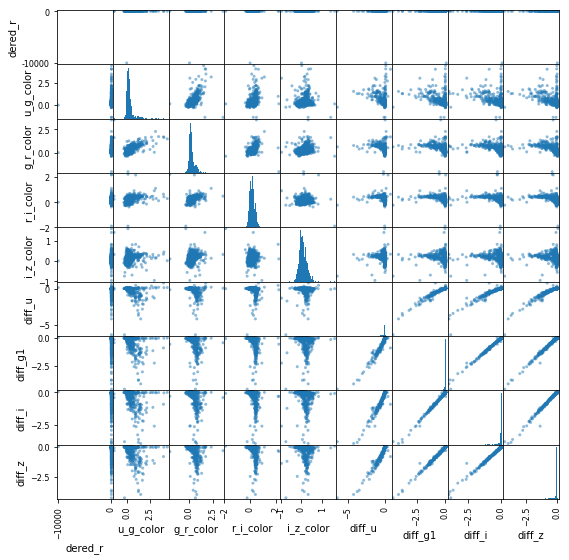

In [30]:
# What about the inputs?
column_subset = ['dered_r', 'u_g_color', 'g_r_color',
                 'r_i_color', 'i_z_color', 'diff_u', 'diff_g1', 'diff_i', 'diff_z']
pd.plotting.scatter_matrix(qso[:1000][column_subset], figsize=[9,9], hist_kwds={'bins': 100});

# I wanted to use DFM's corner here... nicer for publication output, but proved more of a pain to get working...

The distributions involving `dered_r` look weird because it has "missing values" indicated with -10000. These could be converted to missing values in the pandas data frame. Some machine learning methods (like XGBoost) have special missing value support, but most don't.

When there are only a few missing values (like here) the easiest thing to do is just throw out those rows (so we do). But in some problems many or even most rows contain a missing value somewhere. One fix is to set these values to zero (or a median value), and add another column for each original feature that contains zeros and ones, indicating whether the value is missing or not. The machine learning method can then learn what to do with missing values.

There are some fairly strong correlations between some of the features. In linear regression, "co-linear" features mean that it's hard to interpret the features. But if we "regularize" we can keep all these features, and it might be fine. In fact it might be better than throwing features away.

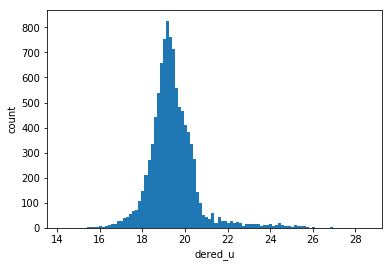

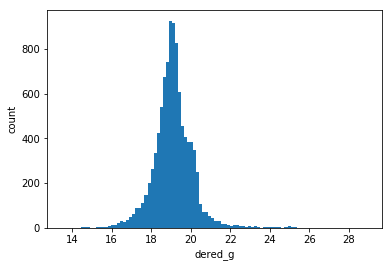

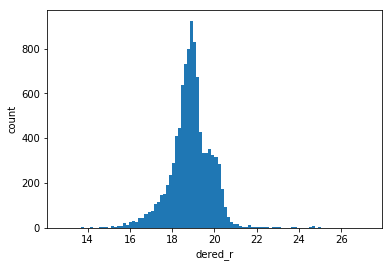

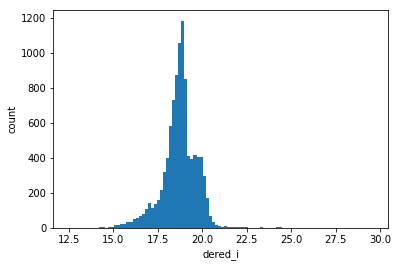

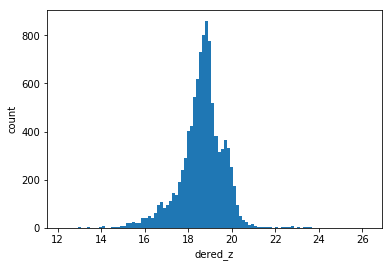

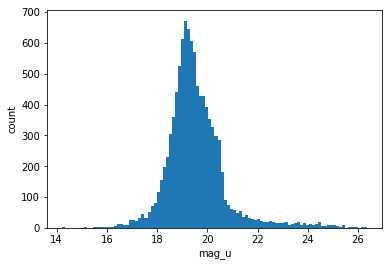

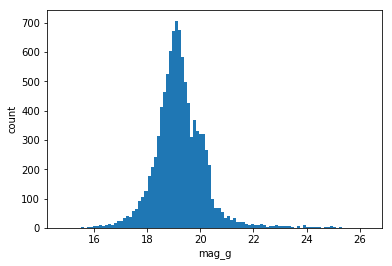

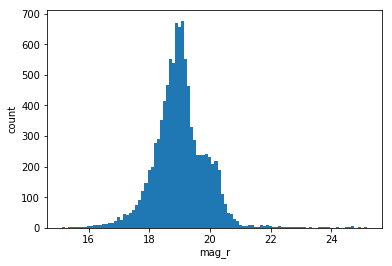

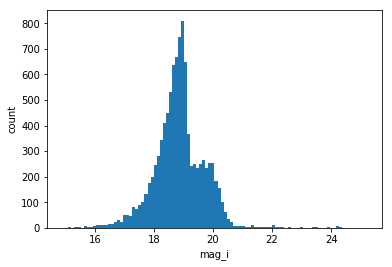

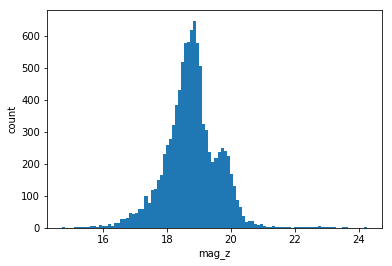

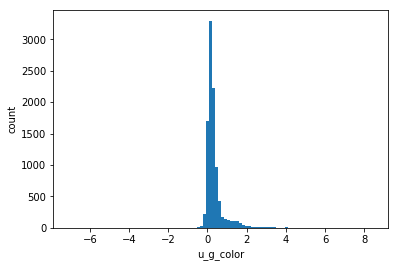

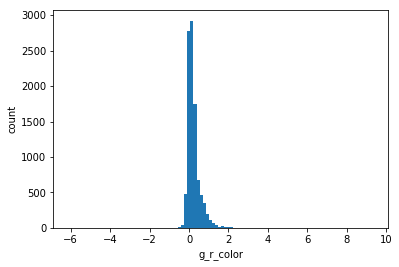

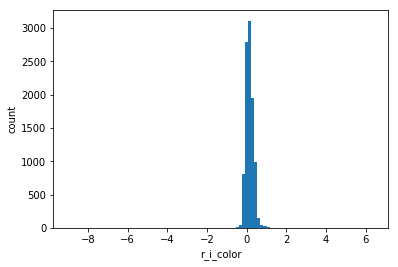

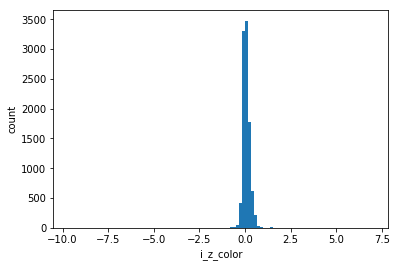

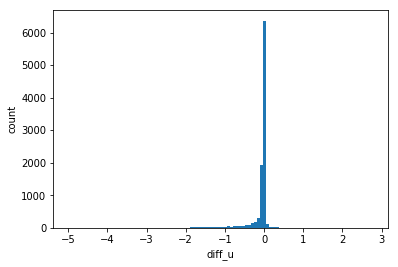

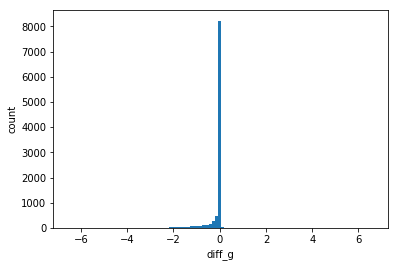

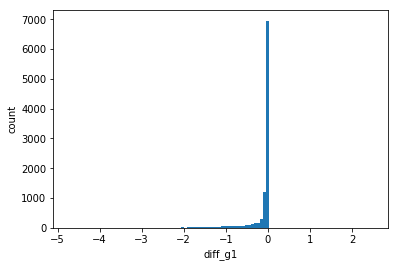

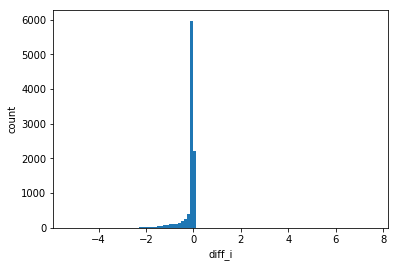

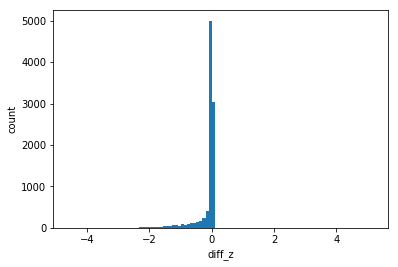

In [31]:
# Cut used previously by Bloom:
qso_X = qso.drop(columns=['ra', 'dec', 'class', 'spec_z'])
#qso_X = qso[column_subset]  # Bloom dropped many more features. Can debate whether should.
cut = (qso_X['dered_r'] > -9999) & (qso_X['g_r_color'] > -10) & (qso_X['g_r_color'] < 10) & (qso_X['diff_u'] > -5)
qso_X = qso_X[cut]
qso_y = qso_y[cut]

# I decided to inspect all of the histograms:
for col in qso_X.columns:
    plt.figure()
    plt.hist(qso_X[col], 100);
    plt.xlabel(col)
    plt.ylabel('count');

Some of the histograms look like they are made out of two bumps. Is there an obvious clustering that would be worth investigating?

The `diff_*` quantities look like they "should" be -ve. If they were I might take the log of minus these values. Also it makes me suspect the +ve values artifacts of previous data processing? The SQL statement said `... dered_z - mag_z AS diff_z ...`. Maybe positive `diff_*` quantities are unphysical. I haven't done anything further for now though.

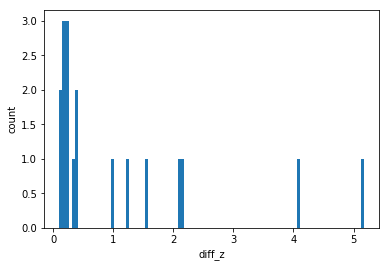

In [11]:
# Taking a look at the tail of diff_z
plt.hist(qso_X['diff_z'][qso_X['diff_z'] > 0.1], 100)
plt.xlabel('diff_z'); plt.ylabel('count');

I haven't, but in a first pass I'd consider discarding these large values. I'm tempted to force `diff_z` to be negative, and then use log(-diff_z) as a feature. (But I haven't.)

Looking at 84% of cases


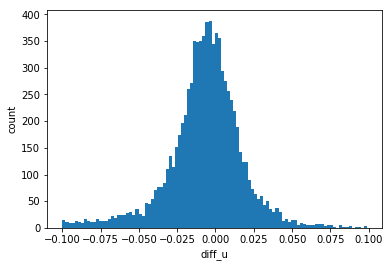

In [12]:
# Distribution on diff_u exceedingly sharp, but doesn't have "atom" at zero:
plt.hist(qso_X['diff_u'][abs(qso_X['diff_u']) < 0.1], 100)
plt.xlabel('diff_u'); plt.ylabel('count')
print('Looking at %0.0f%% of cases' % (100.0 * (abs(qso_X['diff_u']) < 0.1).sum() / len(qso_X)))

In [13]:
# Standardizing inputs. Often, but not always, a useful default.
qso_X = qso_X - qso_X.mean(axis=0).values
qso_X = qso_X / qso_X.std(axis=0).values

## Dataset splits

**This part is important.** We split our data into training, validation, and test splits.

Good training error might not mean anything: it's easy to get zero training error (e.g., nearest neighbour regression with K=1). Validation sets (AKA "development sets") let us compare different models. However, it's easy to fool-yourself (make a fool of yourself) by making many random tweaks – when we start to fit the validation by making many comparisons, it's no longer representative of future performance(†). A held out test set should be used *at the end* to do a final comparison, of a small number of alternatives.

(†) Here the validation set is not representative of future performance, because the 10,000 QSO's we have are not representative of the whole SDSS catalogue. We are probably also interested mainly in large red-shift sources.

In [14]:
N = len(qso_y)
N_val = int(N * 0.10)
N_test = int(N * 0.10)
N_train = N - N_val - N_test
qso_X_train = qso_X[:N_train]
qso_y_train = qso_y[:N_train]
qso_X_val = qso_X[N_train:(N_train + N_val)]
qso_y_val = qso_y[N_train:(N_train + N_val)]
# ...can fill in qso_X_test and qso_y_test when I need them...

## Fit some models

val error = 0.511 +/- 0.165
train error = 0.374 +/- 0.013


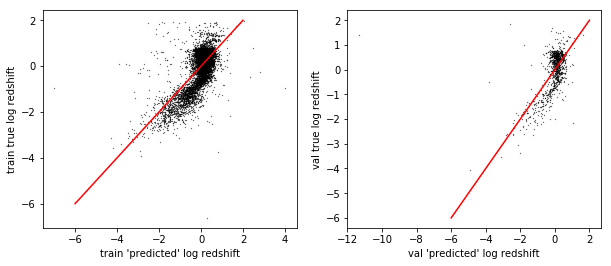

In [15]:
import scipy.stats
def mse_stderr(y1, y2):
    r2 = (y1 - y2) ** 2
    return np.mean(r2), scipy.stats.sem(r2)
    
y_train_true = qso_y_train.values
y_val_true = qso_y_val.values

def fit_and_evaluate(model):
    model.fit(qso_X_train, qso_y_train)
    y_val_pred = model.predict(qso_X_val)
    y_train_pred = model.predict(qso_X_train)
    
    plt.figure(figsize=[10,4])
    plt.subplot(1, 2, 1)
    plt.plot(y_train_pred, y_train_true, '.k', ms=0.5)
    plt.plot([-6, 2], [-6, 2], '-r')
    plt.xlabel("train 'predicted' log redshift"); plt.ylabel("train true log redshift");
    plt.subplot(1, 2, 2)
    plt.plot(y_val_pred, y_val_true, '.k', ms=0.5)
    plt.plot([-6, 2], [-6, 2], '-r')
    plt.xlabel("val 'predicted' log redshift"); plt.ylabel("val true log redshift");
    
    print('val error = %0.3f +/- %0.3f' % mse_stderr(y_val_true, y_val_pred))
    print('train error = %0.3f +/- %0.3f' % mse_stderr(y_train_true, y_train_pred))
    
    return y_val_pred

import sklearn.linear_model
fit_and_evaluate(sklearn.linear_model.Ridge(alpha=10.0));

From the plots it looks like the predictions are working similarly on the two datasets. The plots mainly look different because there are many more points in the training set than the validation set.

Our predictions are worse on the validation examples than the training examples. That is common, and not necessarily a sign of over-fitting. Although it is a sign we could learn more.

There is a clear sign of under-fitting. If we systematically increased the predictions where we're currently predicting log-redshifts of less than zero, we'd perform better. We need a non-linear predictor. We could do that by taking non-linear functions of our inputs and adding columns to our data matrix. But instead we'll try another regression method...

val error = 0.245 +/- 0.034
train error = 0.000 +/- 0.000


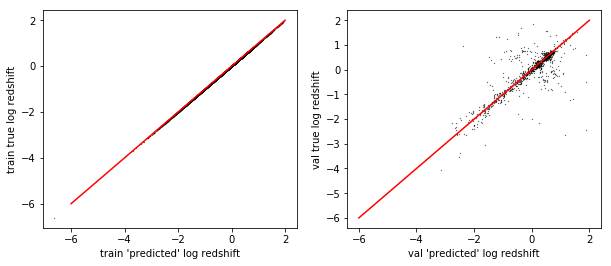

In [16]:
import sklearn.tree
fit_and_evaluate(sklearn.tree.DecisionTreeRegressor());

Now we probably are overfitting: we have memorized the training set, and we know the red-shift observations are noisy. However, we are generalizing to unseen examples. Our validation error is lower than before. I would prefer this model to the linear regression one.

After reading the documentation I tweak one of the hyper-parameters of the method to stop it from matching the training set so closely. I also try ensembling different models into a "random forest".

val error = 0.169 +/- 0.019
train error = 0.133 +/- 0.007


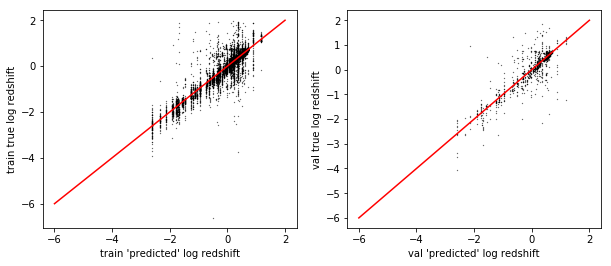

In [17]:
import sklearn.tree
val_pred_single_tree = fit_and_evaluate(sklearn.tree.DecisionTreeRegressor(min_samples_leaf=50));

val error = 0.135 +/- 0.015
train error = 0.027 +/- 0.002


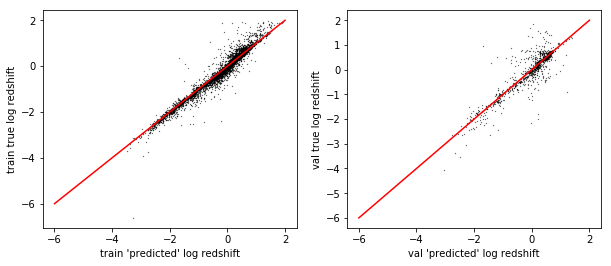

In [18]:
# The version of sklearn I have installed calls something that's going to be deprecated from Numpy.
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

import sklearn.ensemble
val_pred_ensemble = fit_and_evaluate(sklearn.ensemble.RandomForestRegressor(10));

These restricted or ensembled decision trees seem to be working a bit better. However, you may not be convinced given how big the error bars on the validation performance are.

Below we do a *paired comparison*. We look at the difference in square error between the two methods on each example. It looks like ensembling did help (but if we computed a p-value from a t-test, it wouldn't be *tiny*). Also, we have only showed that this particular ensemble fit is generalizing better. To look at how robust the ensembling procedure is, we'd have to run it multiple times. We are also not looking at how robust the methods are on different datasets: we could re-partition our data to assess that. Before reporting an "error-bar" on a result, we need to be clear why we want one – what question we are asking.

In [19]:
ensemble_losses = (val_pred_ensemble - y_val_true)**2
single_tree_losses = (val_pred_single_tree - y_val_true)**2

differences = single_tree_losses - ensemble_losses
print('ensemble better by %0.3f +/- %0.3f' % (differences.mean(), scipy.stats.sem(differences)))

ensemble better by 0.035 +/- 0.010


## Understanding the residuals

When points lie close to a diagonal line, it's often good to subtract off the diagonal so that we use more of the area of the plot.

In the plot below I show the errors made as a function of observed (rather than predicted) red-shift. We see that we are systematically under-estimating large red-shifts. However, unlike the discussion under the linear regression plot, there is no easy fix here. If we systematically increase our large estimates, we'll spuriously predict large red-shifts for many examples. The plots above this section didn't show any obvious bias that we can correct.

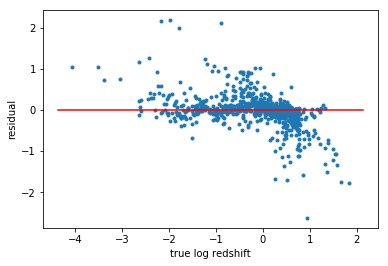

In [20]:
plt.plot(y_val_true, val_pred_ensemble - y_val_true, '.')
plt.plot(plt.xlim(), [0,0], 'r-')
plt.xlabel('true log redshift'); plt.ylabel('residual');

As a first step to understanding whether we could improve things, I invent a classification task. I fit a model to predict whether the log-redshift is bigger than a threshold.

Although on the training set the classifier separates out large-redshifts, it is unable to confidently do so on the validation set. If a model can't be certain a red-shift is large, it has to hedge its bets and predict a moderate value. Sadly I think we need more data and/or more knowledge injected into the analysis. I doubt escalating to more advanced ML methods will help here. (Also, again, we need a more representative dataset!)

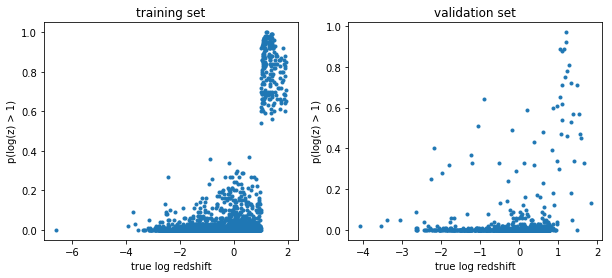

In [21]:
#model = sklearn.linear_model.LogisticRegression(C=(1 / 10.0))
model = sklearn.ensemble.RandomForestClassifier(100)
threshold = 1.0
model.fit(qso_X_train, qso_y_train > threshold)

y_train_pred = model.predict_proba(qso_X_train)[:,1]
y_val_pred = model.predict_proba(qso_X_val)[:,1]

plt.figure(figsize=(10,4))
plt.clf()
plt.subplot(1, 2, 1)
plt.title('training set');
plt.plot(y_train_true, y_train_pred, '.')
plt.xlabel('true log redshift'); plt.ylabel('p(log(z) > %g)' % threshold)
plt.subplot(1, 2, 2)
plt.title('validation set')
plt.plot(y_val_true, y_val_pred, '.');
plt.xlabel('true log redshift'); plt.ylabel('p(log(z) > %g)' % threshold);